# Graph Neural Networks on ogbn-products

Node classification on the ogbn-products dataset from the Open Graph Benchmark (OGB).  
The task is to predict the product category (47 classes) of Amazon products based on co-purchasing relationships.

**Models evaluated:**
- GCN (Graph Convolutional Network)
- GraphSAGE (Inductive Representation Learning)
- GAT (Graph Attention Network)
- SIGN (Scalable Inception Graph Neural Network)

**Pipeline:**
1. Dataset loading and EDA
2. Graph structure visualization
3. Model definitions
4. Hyperparameter search
5. Training with checkpoint saving
6. Evaluation and comparison
7. Visualizations and conclusions

## 1. Setup

In [1]:
# !pip install torch torchvision --quiet
# !pip install torch-geometric --quiet
# !pip install ogb --quiet
# !pip install matplotlib seaborn scikit-learn pandas numpy networkx --quiet

In [2]:
# !pip install torch-sparse

In [3]:
import os
import time
import json
import copy
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from itertools import product as iterproduct

import torch
import torch.nn as nn
import torch.nn.functional as F

import torch_geometric
from torch_geometric.nn import GCNConv, SAGEConv, GATConv
from torch_geometric.loader import NeighborLoader
from torch_geometric.utils import to_networkx

from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, classification_report
import networkx as nx

# Directories
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('plots', exist_ok=True)

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version: {torch.__version__}')
print(f'PyG version:     {torch_geometric.__version__}')
print(f'Device:          {DEVICE}')

PyTorch version: 2.7.0+cu128
PyG version:     2.7.0
Device:          cuda


## 2. Dataset Loading and EDA

ogbn-products is a large-scale undirected graph representing the Amazon product co-purchasing network.  
Nodes are products, edges indicate co-purchases, node features are 100-dim bag-of-words embeddings from product descriptions.  
The task is multi-class node classification into 47 top-level Amazon product categories.

In [4]:
import torch

from torch_geometric.data.data import (
    Data,
    DataEdgeAttr,
    DataTensorAttr,
)

from torch_geometric.data.storage import (
    BaseStorage,
    EdgeStorage,
    GlobalStorage,
    NodeStorage,
)

torch.serialization.add_safe_globals([
    Data,
    DataEdgeAttr,
    DataTensorAttr,
    BaseStorage,
    EdgeStorage,
    GlobalStorage,
    NodeStorage,
])

In [5]:
from ogb.nodeproppred import PygNodePropPredDataset, Evaluator

dataset = PygNodePropPredDataset(name='ogbn-products', root='data')
evaluator = Evaluator(name='ogbn-products')

data = dataset[0]
split_idx = dataset.get_idx_split()

train_idx = split_idx['train']
valid_idx = split_idx['valid']
test_idx  = split_idx['test']

print('=== Dataset Statistics ===')
print(f'Nodes:           {data.num_nodes:,}')
print(f'Edges:           {data.num_edges:,}')
print(f'Node features:   {data.num_node_features}')
print(f'Classes:         {dataset.num_classes}')
print(f'Train nodes:     {len(train_idx):,}')
print(f'Val nodes:       {len(valid_idx):,}')
print(f'Test nodes:      {len(test_idx):,}')
avg_deg = data.num_edges / data.num_nodes
print(f'Avg degree:      {avg_deg:.2f}')

=== Dataset Statistics ===
Nodes:           2,449,029
Edges:           123,718,280
Node features:   100
Classes:         47
Train nodes:     196,615
Val nodes:       39,323
Test nodes:      2,213,091
Avg degree:      50.52


### Class distribution

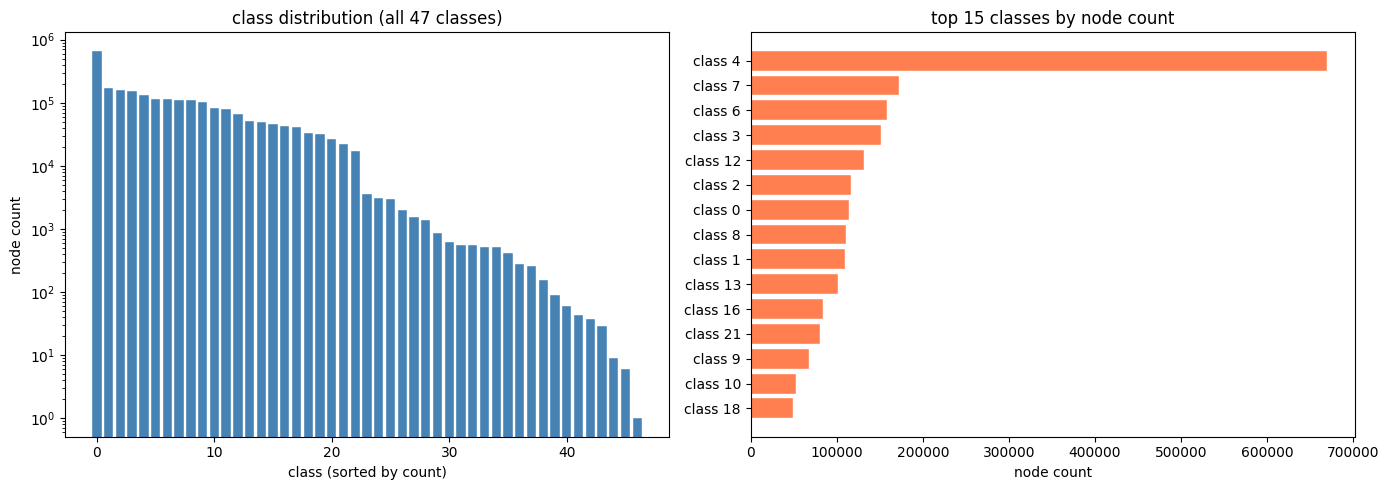

Saved: plots/class_distribution.png


In [6]:
labels = data.y.squeeze().numpy()
unique, counts = np.unique(labels, return_counts=True)
class_counts = pd.Series(counts, index=unique).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full class distribution bar chart
axes[0].bar(range(len(class_counts)), class_counts.values, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('class (sorted by count)')
axes[0].set_ylabel('node count')
axes[0].set_title('class distribution (all 47 classes)')
axes[0].set_yscale('log')

# Top-15 classes
top15 = class_counts.head(15)
axes[1].barh(range(len(top15)), top15.values, color='coral', edgecolor='white', linewidth=0.3)
axes[1].set_yticks(range(len(top15)))
axes[1].set_yticklabels([f'class {i}' for i in top15.index])
axes[1].set_xlabel('node count')
axes[1].set_title('top 15 classes by node count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('plots/class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plots/class_distribution.png')

The class distribution is highly imbalanced — the most frequent category contains orders of magnitude more nodes than the rarest ones. This motivates using weighted metrics (macro F1) in addition to accuracy.

### Node feature analysis

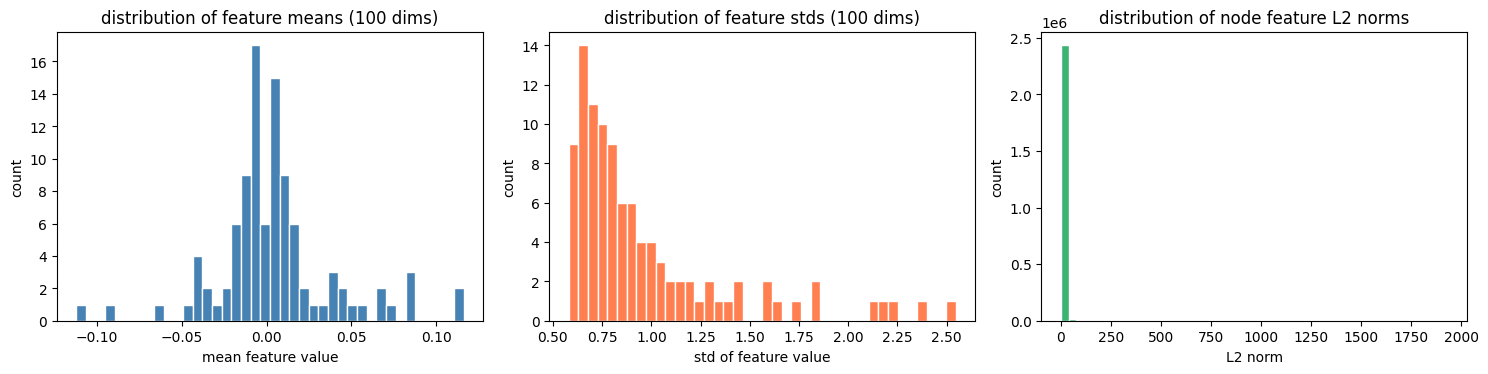

Saved: plots/feature_analysis.png


In [7]:
feats = data.x.numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Feature mean distribution
feat_means = feats.mean(axis=0)
axes[0].hist(feat_means, bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('mean feature value')
axes[0].set_ylabel('count')
axes[0].set_title('distribution of feature means (100 dims)')

# Feature std distribution
feat_stds = feats.std(axis=0)
axes[1].hist(feat_stds, bins=40, color='coral', edgecolor='white')
axes[1].set_xlabel('std of feature value')
axes[1].set_ylabel('count')
axes[1].set_title('distribution of feature stds (100 dims)')

# Per-node L2 norm
norms = np.linalg.norm(feats, axis=1)
axes[2].hist(norms, bins=50, color='mediumseagreen', edgecolor='white')
axes[2].set_xlabel('L2 norm')
axes[2].set_ylabel('count')
axes[2].set_title('distribution of node feature L2 norms')

plt.tight_layout()
plt.savefig('plots/feature_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plots/feature_analysis.png')

### Degree distribution

Min degree: 0  Max degree: 17481  Mean: 50.52  Median: 26


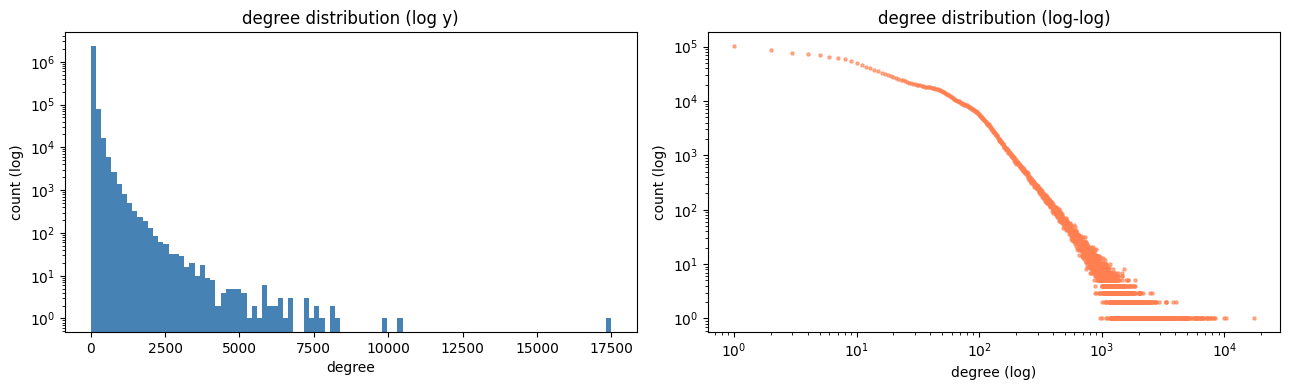

Saved: plots/degree_distribution.png


In [8]:
from torch_geometric.utils import degree

row = data.edge_index[0]
deg = degree(row, num_nodes=data.num_nodes).numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(deg, bins=100, color='steelblue', edgecolor='none', log=True)
axes[0].set_xlabel('degree')
axes[0].set_ylabel('count (log)')
axes[0].set_title('degree distribution (log y)')

# log-log plot (power law check)
deg_unique, deg_counts = np.unique(deg, return_counts=True)
mask = (deg_unique > 0) & (deg_counts > 0)
axes[1].scatter(deg_unique[mask], deg_counts[mask], s=5, color='coral', alpha=0.6)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('degree (log)')
axes[1].set_ylabel('count (log)')
axes[1].set_title('degree distribution (log-log)')

print(f'Min degree: {deg.min():.0f}  Max degree: {deg.max():.0f}  Mean: {deg.mean():.2f}  Median: {np.median(deg):.0f}')

plt.tight_layout()
plt.savefig('plots/degree_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plots/degree_distribution.png')

The log-log plot shows a heavy-tailed (approximately power-law) degree distribution, typical of real-world product co-purchase graphs. Most nodes have low degree, while a few hub products are co-purchased with thousands of others.

### Subgraph visualization

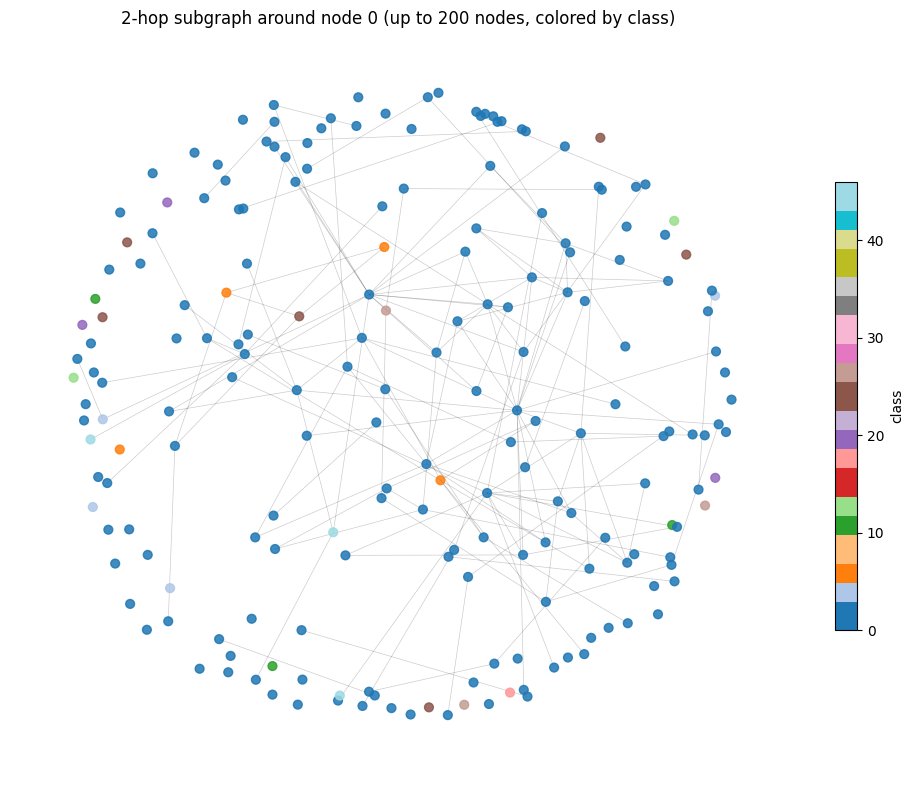

Saved: plots/subgraph_visualization.png


In [9]:
# Visualize a small ego-subgraph around a high-degree node
from torch_geometric.utils import k_hop_subgraph

# Pick a node from training set
center_node = train_idx[0].item()
subset, sub_edge_index, mapping, _ = k_hop_subgraph(
    node_idx=center_node, num_hops=2,
    edge_index=data.edge_index, relabel_nodes=True
)

# Keep only up to 200 nodes for readability
if len(subset) > 200:
    keep = torch.randperm(len(subset))[:200]
    keep_sorted, _ = keep.sort()

    subset_small = subset[keep_sorted]

    # map old node ids -> new consecutive ids
    old_to_new = {old.item(): new for new, old in enumerate(keep_sorted)}

    # keep only edges between kept nodes
    src = sub_edge_index[0]
    dst = sub_edge_index[1]

    mask = torch.isin(src, keep_sorted) & torch.isin(dst, keep_sorted)

    filtered_edges = sub_edge_index[:, mask]

    # relabel edges
    relabeled_edges = torch.tensor([
        [old_to_new[s.item()] for s in filtered_edges[0]],
        [old_to_new[d.item()] for d in filtered_edges[1]]
    ])

    sub_edge_index_small = relabeled_edges

else:
    subset_small = subset
    sub_edge_index_small = sub_edge_index

sub_labels = labels[subset_small.numpy()]

G = nx.Graph()
G.add_nodes_from(range(len(subset_small)))
G.add_edges_from(sub_edge_index_small.t().tolist())

pos = nx.spring_layout(G, seed=SEED, k=0.5)
cmap = plt.cm.get_cmap('tab20', dataset.num_classes)

fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx_nodes(G, pos, node_color=sub_labels, cmap=cmap,
                       node_size=40, alpha=0.85, ax=ax)
nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.5, ax=ax)
ax.set_title(f'2-hop subgraph around node {center_node} (up to 200 nodes, colored by class)')
ax.axis('off')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, dataset.num_classes - 1))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='class', shrink=0.6)
plt.tight_layout()
plt.savefig('plots/subgraph_visualization.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plots/subgraph_visualization.png')

The subgraph shows clusters of same-class nodes connected densely, validating that local neighborhood structure is informative for classification.

### Split statistics

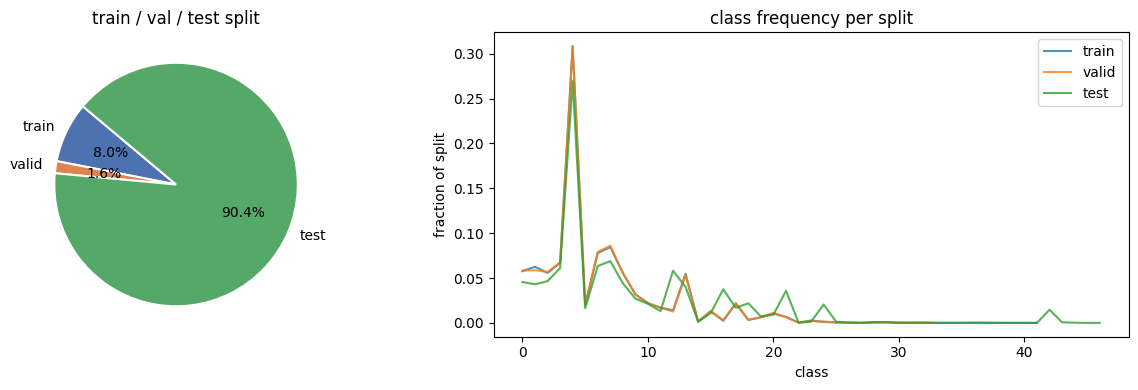

Saved: plots/split_statistics.png


In [10]:
split_names = ['train', 'valid', 'test']
split_sizes = [len(train_idx), len(valid_idx), len(test_idx)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Pie chart of split sizes
colors = ['#4C72B0', '#DD8452', '#55A868']
axes[0].pie(split_sizes, labels=split_names, autopct='%1.1f%%', colors=colors,
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('train / val / test split')

# Class distribution per split
for split_name, idx in zip(split_names, [train_idx, valid_idx, test_idx]):
    split_labels = labels[idx.numpy()]
    u, c = np.unique(split_labels, return_counts=True)
    axes[1].plot(u, c / c.sum(), label=split_name, alpha=0.8)
axes[1].set_xlabel('class')
axes[1].set_ylabel('fraction of split')
axes[1].set_title('class frequency per split')
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/split_statistics.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plots/split_statistics.png')

The OGB split is time-based (not random): training uses earlier products, test uses more recent ones. This makes the task harder than a random split since the distribution shifts slightly between splits.

## 3. Data Preparation

ogbn-products has 2.4M nodes. Full-graph training would require storing the entire adjacency in GPU memory.  
We use **mini-batch neighbor sampling** via `NeighborLoader`, which samples fixed-size neighborhoods for each node.

In [11]:
# Add boolean masks to the data object for compatibility
data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.train_mask[train_idx] = True
data.val_mask   = torch.zeros(data.num_nodes, dtype=torch.bool)
data.val_mask[valid_idx]   = True
data.test_mask  = torch.zeros(data.num_nodes, dtype=torch.bool)
data.test_mask[test_idx]   = True

data = data.to(DEVICE)

# NeighborLoader parameters
BATCH_SIZE   = 1024
NUM_NEIGHBORS = [15, 10]  # samples per hop

train_loader = NeighborLoader(
    data,
    num_neighbors=NUM_NEIGHBORS,
    batch_size=BATCH_SIZE,
    input_nodes=train_idx.to(DEVICE),
    shuffle=True,
    num_workers=0,
)

val_loader = NeighborLoader(
    data,
    num_neighbors=NUM_NEIGHBORS,
    batch_size=BATCH_SIZE * 2,
    input_nodes=valid_idx.to(DEVICE),
    shuffle=False,
    num_workers=0,
)

test_loader = NeighborLoader(
    data,
    num_neighbors=NUM_NEIGHBORS,
    batch_size=BATCH_SIZE * 2,
    input_nodes=test_idx.to(DEVICE),
    shuffle=False,
    num_workers=0,
)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

Train batches: 193
Val batches:   20
Test batches:  1081


## 4. Model Definitions

### GCN - Graph Convolutional Network

GCN aggregates neighbor features using a symmetric normalized adjacency matrix.  
Each layer: $H^{(l+1)} = \sigma(\hat{D}^{-1/2}\hat{A}\hat{D}^{-1/2} H^{(l)} W^{(l)})$

In [12]:
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels,
                 num_layers=3, dropout=0.5):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        self.dropout = dropout

        self.convs.append(GCNConv(in_channels, hidden_channels))
        self.bns.append(nn.BatchNorm1d(hidden_channels))
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
            self.bns.append(nn.BatchNorm1d(hidden_channels))
        self.convs.append(GCNConv(hidden_channels, out_channels))

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.convs[-1](x, edge_index)

    def get_embeddings(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
        return x

### GraphSAGE - Inductive Representation Learning

GraphSAGE samples a fixed-size neighborhood and concatenates the ego node with the aggregated neighbor embedding.  
Supports inductive learning on unseen nodes at test time.

In [13]:
class GraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels,
                 num_layers=3, dropout=0.5, aggr='mean'):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        self.dropout = dropout

        self.convs.append(SAGEConv(in_channels, hidden_channels, aggr=aggr))
        self.bns.append(nn.BatchNorm1d(hidden_channels))
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels, aggr=aggr))
            self.bns.append(nn.BatchNorm1d(hidden_channels))
        self.convs.append(SAGEConv(hidden_channels, out_channels, aggr=aggr))

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.convs[-1](x, edge_index)

    def get_embeddings(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
        return x

### GAT - Graph Attention Network

GAT uses learned attention coefficients to weight neighbor contributions.  
Multi-head attention is used in intermediate layers to stabilize learning.

In [14]:
class GAT(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels,
                 num_layers=3, heads=4, dropout=0.5):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        self.dropout = dropout

        self.convs.append(GATConv(in_channels, hidden_channels, heads=heads,
                                   dropout=dropout, concat=True))
        self.bns.append(nn.BatchNorm1d(hidden_channels * heads))
        for _ in range(num_layers - 2):
            self.convs.append(GATConv(hidden_channels * heads, hidden_channels,
                                       heads=heads, dropout=dropout, concat=True))
            self.bns.append(nn.BatchNorm1d(hidden_channels * heads))
        self.convs.append(GATConv(hidden_channels * heads, out_channels,
                                   heads=1, dropout=dropout, concat=False))

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.elu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.convs[-1](x, edge_index)

    def get_embeddings(self, x, edge_index):
        for i, conv in enumerate(self.convs[:-1]):
            x = conv(x, edge_index)
            x = self.bns[i](x)
            x = F.elu(x)
        return x

### SIGN - Scalable Inception Graph Neural Network

SIGN precomputes multi-hop diffusions $\{X, AX, A^2X, \ldots, A^K X\}$ and feeds them through separate linear layers combined via an MLP.  
This decouples the graph diffusion from the learning phase, making it very scalable.

In [15]:
from torch_geometric.transforms import SIGN as SIGNTransform

class SIGNModel(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels,
                 K=3, dropout=0.5):
        super().__init__()
        self.K = K
        self.dropout = dropout
        # One linear per hop (including 0-hop = raw features)
        self.lins = nn.ModuleList([
            nn.Linear(in_channels, hidden_channels) for _ in range(K + 1)
        ])
        self.bns = nn.ModuleList([
            nn.BatchNorm1d(hidden_channels) for _ in range(K + 1)
        ])
        # MLP to combine
        self.mlp = nn.Sequential(
            nn.Linear((K + 1) * hidden_channels, hidden_channels),
            nn.BatchNorm1d(hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, out_channels),
        )

    def forward(self, xs):
        # xs is a list of K+1 tensors, each (N, in_channels)
        outs = []
        for i, x in enumerate(xs):
            h = self.lins[i](x)
            h = self.bns[i](h)
            h = F.relu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
            outs.append(h)
        out = torch.cat(outs, dim=-1)
        return self.mlp(out)

    def get_embeddings(self, xs):
        outs = []
        for i, x in enumerate(xs):
            h = self.lins[i](x)
            h = self.bns[i](h)
            h = F.relu(h)
            outs.append(h)
        out = torch.cat(outs, dim=-1)
        return out


def precompute_sign(data, K):
    """Pre-compute K-hop diffusion matrices and store on data object."""
    import torch_geometric.transforms as T
    data_cpu = data.cpu()
    transform = SIGNTransform(K)
    data_sign = transform(data_cpu)
    # xs stores the diffused features as xs_0..xs_K attributes
    return data_sign

print('SIGN model defined.')

SIGN model defined.


## 5. Training and Evaluation Utilities

In [16]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    total_nodes = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index)
        # only compute loss on the seed nodes (first batch_size nodes)
        n = batch.batch_size
        loss = F.cross_entropy(out[:n], batch.y[:n].squeeze())
        loss.backward()
        optimizer.step()
        total_loss  += loss.item() * n
        total_nodes += n
    return total_loss / total_nodes


@torch.no_grad()
def evaluate(model, loader, evaluator, device):
    model.eval()
    y_pred_list = []
    y_true_list = []
    for batch in loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index)
        n = batch.batch_size
        pred = out[:n].argmax(dim=-1, keepdim=True)
        y_pred_list.append(pred.cpu())
        y_true_list.append(batch.y[:n].cpu())
    y_pred = torch.cat(y_pred_list, dim=0)
    y_true = torch.cat(y_true_list, dim=0)
    acc = evaluator.eval({'y_true': y_true, 'y_pred': y_pred})['acc']
    return acc, y_true, y_pred


def train_model(model_class, model_kwargs, model_name, train_loader, val_loader,
                lr, weight_decay, epochs, device, evaluator,
                patience=10, checkpoint_prefix='best'):
    """
    Full training loop with early stopping and checkpoint saving.
    Returns: dict with train/val loss and accuracy histories.
    """
    model = model_class(**model_kwargs).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5
    )

    history = {'train_loss': [], 'val_acc': []}
    best_val_acc   = 0.0
    patience_count = 0
    print(f'      ', end='')

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        loss = train_epoch(model, train_loader, optimizer, device)
        val_acc, _, _ = evaluate(model, val_loader, evaluator, device)
        scheduler.step(val_acc)

        history['train_loss'].append(loss)
        history['val_acc'].append(val_acc)
        print("|", end="", flush=True)

        if val_acc > best_val_acc:
            best_val_acc   = val_acc
            patience_count = 0
            ckpt_path = f'checkpoints/{checkpoint_prefix}_{model_name}.pt'
            torch.save({
                'epoch': epoch,
                'model_state': model.state_dict(),
                'val_acc': val_acc,
                'model_kwargs': model_kwargs,
                'history': history,
            }, ckpt_path)
        else:
            patience_count += 1

        if epoch % 5 == 0:
            print(f'  Epoch {epoch:3d} | loss {loss:.4f} | val acc {val_acc:.4f} '
                  f'| best {best_val_acc:.4f} | {time.time()-t0:.1f}s')

        if patience_count >= patience:
            print(f'  Early stopping at epoch {epoch}')
            break

    print()
    # Reload best checkpoint
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    print(f'  Best val acc: {best_val_acc:.4f}')
    return model, history, best_val_acc


# --- Checkpoint helpers for resumable search ---
def search_ckpt_path(model_name, tag):
    return f'checkpoints/search_{model_name}_{tag}.pt'

def save_search_ckpt(model_name, tag, model, best_val, model_kwargs):
    torch.save({
        'model_state': model.state_dict(),
        'best_val': best_val,
        'model_kwargs': model_kwargs,
    }, search_ckpt_path(model_name, tag))

def load_search_ckpt(model_name, tag, device='cpu'):
    path = search_ckpt_path(model_name, tag)
    if os.path.exists(path):
        return torch.load(path, map_location=device)
    return None


# --- Helpers for persisting comparison data across restarts ---
COMPARE_DIR = 'checkpoints'

def save_comparison_data(name, data):
    path = os.path.join(COMPARE_DIR, f'{name}.pt')
    torch.save(data, path)

def load_comparison_data(name, device='cpu'):
    path = os.path.join(COMPARE_DIR, f'{name}.pt')
    if os.path.exists(path):
        return torch.load(path, map_location=device)
    return None


print('Training utilities defined.')

Training utilities defined.


## 6. Hyperparameter Search

For each model we run a grid search over a set of hyperparameters.  
Training is done for a reduced number of epochs per configuration, and the best configuration is selected based on validation accuracy.

In [17]:
NUM_CLASSES    = dataset.num_classes    # 47
IN_CHANNELS    = dataset.num_node_features  # 100
SEARCH_EPOCHS  = 20   # short search
FINAL_EPOCHS   = 50   # full training of best config
PATIENCE       = 8

all_results = []  # will collect all hp search results

print(f'Input dim: {IN_CHANNELS}, Classes: {NUM_CLASSES}')

Input dim: 100, Classes: 47


### GCN hyperparameter search

In [18]:
gcn_grid = {
    'hidden_channels': [128, 256],
    'num_layers':      [2, 3],
    'dropout':         [0.3, 0.5],
    'lr':              [0.01, 0.001],
    'weight_decay':    [0.0],
}

gcn_keys   = list(gcn_grid.keys())
gcn_combos = list(iterproduct(*gcn_grid.values()))
print(f'GCN: {len(gcn_combos)} configurations')

gcn_search_results = []

for combo in gcn_combos:
    params = dict(zip(gcn_keys, combo))
    model_kwargs = {
        'in_channels':     IN_CHANNELS,
        'hidden_channels': params['hidden_channels'],
        'out_channels':    NUM_CLASSES,
        'num_layers':      params['num_layers'],
        'dropout':         params['dropout'],
    }
    tag = f"h{params['hidden_channels']}_l{params['num_layers']}_d{params['dropout']}_lr{params['lr']}"

    ckpt = load_search_ckpt('GCN', tag, DEVICE)
    if ckpt is not None:
        print(f'GCN {tag} (loaded from checkpoint)')
        best_val = ckpt['best_val']
    else:
        print(f'GCN {tag}')
        model = GCN(**model_kwargs).to(DEVICE)
        optimizer = torch.optim.Adam(
            model.parameters(), lr=params['lr'], weight_decay=params['weight_decay']
        )

        best_val = 0.0
        print(f'      ', end='')
        for epoch in range(1, SEARCH_EPOCHS + 1):
            loss = train_epoch(model, train_loader, optimizer, DEVICE)
            val_acc, _, _ = evaluate(model, val_loader, evaluator, DEVICE)
            if val_acc > best_val:
                best_val = val_acc
            print("|", end="", flush=True)
        print()

        save_search_ckpt('GCN', tag, model, best_val, model_kwargs)

    row = {'model': 'GCN', 'val_acc': best_val, **params}
    gcn_search_results.append(row)
    all_results.append(row)
    print(f'  -> val acc {best_val:.4f}')

df_gcn = pd.DataFrame(gcn_search_results).sort_values('val_acc', ascending=False)
print('\nGCN search results:')
print(df_gcn.to_string(index=False))

GCN: 16 configurations
GCN h128_l2_d0.3_lr0.01 (loaded from checkpoint)
  -> val acc 0.9034
GCN h128_l2_d0.3_lr0.001 (loaded from checkpoint)
  -> val acc 0.9011
GCN h128_l2_d0.5_lr0.01 (loaded from checkpoint)
  -> val acc 0.9014
GCN h128_l2_d0.5_lr0.001 (loaded from checkpoint)
  -> val acc 0.9003
GCN h128_l3_d0.3_lr0.01 (loaded from checkpoint)
  -> val acc 0.9067
GCN h128_l3_d0.3_lr0.001 (loaded from checkpoint)
  -> val acc 0.9053
GCN h128_l3_d0.5_lr0.01 (loaded from checkpoint)
  -> val acc 0.9053
GCN h128_l3_d0.5_lr0.001 (loaded from checkpoint)
  -> val acc 0.9036
GCN h256_l2_d0.3_lr0.01 (loaded from checkpoint)
  -> val acc 0.9070
GCN h256_l2_d0.3_lr0.001 (loaded from checkpoint)
  -> val acc 0.9057
GCN h256_l2_d0.5_lr0.01 (loaded from checkpoint)
  -> val acc 0.9046
GCN h256_l2_d0.5_lr0.001 (loaded from checkpoint)
  -> val acc 0.9049
GCN h256_l3_d0.3_lr0.01 (loaded from checkpoint)
  -> val acc 0.9100
GCN h256_l3_d0.3_lr0.001 (loaded from checkpoint)
  -> val acc 0.9093
GCN 

### GraphSAGE hyperparameter search

In [19]:
sage_grid = {
    'hidden_channels': [128, 256],
    'num_layers':      [2, 3],
    'dropout':         [0.3, 0.5],
    'lr':              [0.01, 0.001],
    'aggr':            ['mean', 'max'],
    'weight_decay':    [0.0],
}

sage_keys   = list(sage_grid.keys())
sage_combos = list(iterproduct(*sage_grid.values()))
print(f'GraphSAGE: {len(sage_combos)} configurations')

sage_search_results = []

for combo in sage_combos:
    params = dict(zip(sage_keys, combo))
    model_kwargs = {
        'in_channels':     IN_CHANNELS,
        'hidden_channels': params['hidden_channels'],
        'out_channels':    NUM_CLASSES,
        'num_layers':      params['num_layers'],
        'dropout':         params['dropout'],
        'aggr':            params['aggr'],
    }
    tag = f"h{params['hidden_channels']}_l{params['num_layers']}_d{params['dropout']}_lr{params['lr']}_aggr{params['aggr']}"

    ckpt = load_search_ckpt('GraphSAGE', tag, DEVICE)
    if ckpt is not None:
        print(f'SAGE {tag} (loaded from checkpoint)')
        best_val = ckpt['best_val']
    else:
        print(f'SAGE {tag}')
        model = GraphSAGE(**model_kwargs).to(DEVICE)
        optimizer = torch.optim.Adam(
            model.parameters(), lr=params['lr'], weight_decay=params['weight_decay']
        )

        best_val = 0.0
        print(f'      ', end='')
        for epoch in range(1, SEARCH_EPOCHS + 1):
            loss = train_epoch(model, train_loader, optimizer, DEVICE)
            val_acc, _, _ = evaluate(model, val_loader, evaluator, DEVICE)
            if val_acc > best_val:
                best_val = val_acc
            print("|", end="", flush=True)
        print()

        save_search_ckpt('GraphSAGE', tag, model, best_val, model_kwargs)

    row = {'model': 'GraphSAGE', 'val_acc': best_val, **params}
    sage_search_results.append(row)
    all_results.append(row)
    print(f'  -> val acc {best_val:.4f}')

df_sage = pd.DataFrame(sage_search_results).sort_values('val_acc', ascending=False)
print('\nGraphSAGE search results:')
print(df_sage.to_string(index=False))

GraphSAGE: 32 configurations
SAGE h128_l2_d0.3_lr0.01_aggrmean (loaded from checkpoint)
  -> val acc 0.9060
SAGE h128_l2_d0.3_lr0.01_aggrmax (loaded from checkpoint)
  -> val acc 0.8793
SAGE h128_l2_d0.3_lr0.001_aggrmean (loaded from checkpoint)
  -> val acc 0.9064
SAGE h128_l2_d0.3_lr0.001_aggrmax (loaded from checkpoint)
  -> val acc 0.8791
SAGE h128_l2_d0.5_lr0.01_aggrmean (loaded from checkpoint)
  -> val acc 0.9036
SAGE h128_l2_d0.5_lr0.01_aggrmax (loaded from checkpoint)
  -> val acc 0.8688
SAGE h128_l2_d0.5_lr0.001_aggrmean (loaded from checkpoint)
  -> val acc 0.9023
SAGE h128_l2_d0.5_lr0.001_aggrmax (loaded from checkpoint)
  -> val acc 0.8737
SAGE h128_l3_d0.3_lr0.01_aggrmean (loaded from checkpoint)
  -> val acc 0.9144
SAGE h128_l3_d0.3_lr0.01_aggrmax (loaded from checkpoint)
  -> val acc 0.8893
SAGE h128_l3_d0.3_lr0.001_aggrmean (loaded from checkpoint)
  -> val acc 0.9126
SAGE h128_l3_d0.3_lr0.001_aggrmax (loaded from checkpoint)
  -> val acc 0.8875
SAGE h128_l3_d0.5_lr0.0

### GAT hyperparameter search

In [20]:
gat_grid = {
    'hidden_channels': [64],
    'num_layers':      [2, 3],
    'heads':           [4],
    'dropout':         [0.3, 0.5],
    'lr':              [0.005, 0.001],
    'weight_decay':    [0.0],
}

gat_keys   = list(gat_grid.keys())
gat_combos = list(iterproduct(*gat_grid.values()))
print(f'GAT: {len(gat_combos)} configurations')

gat_search_results = []

for combo in gat_combos:
    params = dict(zip(gat_keys, combo))
    model_kwargs = {
        'in_channels':     IN_CHANNELS,
        'hidden_channels': params['hidden_channels'],
        'out_channels':    NUM_CLASSES,
        'num_layers':      params['num_layers'],
        'heads':           params['heads'],
        'dropout':         params['dropout'],
    }
    tag = f"h{params['hidden_channels']}_l{params['num_layers']}_hd{params['heads']}_d{params['dropout']}_lr{params['lr']}"

    ckpt = load_search_ckpt('GAT', tag, DEVICE)
    if ckpt is not None:
        print(f'GAT {tag} (loaded from checkpoint)')
        best_val = ckpt['best_val']
    else:
        print(f'GAT {tag}')
        model = GAT(**model_kwargs).to(DEVICE)
        optimizer = torch.optim.Adam(
            model.parameters(), lr=params['lr'], weight_decay=params['weight_decay']
        )

        best_val = 0.0
        print(f'      ', end='')
        for epoch in range(1, SEARCH_EPOCHS + 1):
            loss = train_epoch(model, train_loader, optimizer, DEVICE)
            val_acc, _, _ = evaluate(model, val_loader, evaluator, DEVICE)
            if val_acc > best_val:
                best_val = val_acc
            print("|", end="", flush=True)
        print()

        save_search_ckpt('GAT', tag, model, best_val, model_kwargs)

    row = {'model': 'GAT', 'val_acc': best_val, **params}
    gat_search_results.append(row)
    all_results.append(row)
    print(f'  -> val acc {best_val:.4f}')

df_gat = pd.DataFrame(gat_search_results).sort_values('val_acc', ascending=False)
print('\nGAT search results:')
print(df_gat.to_string(index=False))

GAT: 8 configurations
GAT h64_l2_hd4_d0.3_lr0.005 (loaded from checkpoint)
  -> val acc 0.8997
GAT h64_l2_hd4_d0.3_lr0.001 (loaded from checkpoint)
  -> val acc 0.8929
GAT h64_l2_hd4_d0.5_lr0.005 (loaded from checkpoint)
  -> val acc 0.8931
GAT h64_l2_hd4_d0.5_lr0.001 (loaded from checkpoint)
  -> val acc 0.8834
GAT h64_l3_hd4_d0.3_lr0.005 (loaded from checkpoint)
  -> val acc 0.9007
GAT h64_l3_hd4_d0.3_lr0.001 (loaded from checkpoint)
  -> val acc 0.8969
GAT h64_l3_hd4_d0.5_lr0.005 (loaded from checkpoint)
  -> val acc 0.8910
GAT h64_l3_hd4_d0.5_lr0.001 (loaded from checkpoint)
  -> val acc 0.8859

GAT search results:
model  val_acc  hidden_channels  num_layers  heads  dropout    lr  weight_decay
  GAT 0.900720               64           3      4      0.3 0.005           0.0
  GAT 0.899677               64           2      4      0.3 0.005           0.0
  GAT 0.896854               64           3      4      0.3 0.001           0.0
  GAT 0.893091               64           2      4   

### SIGN feature precomputation

In [21]:
K_MAX = 3

SIGN_CACHE = 'checkpoints/sign_features.pt'
sign_features_ready = False

def compute_sign_diffusions(data, K, chunk_size=2):
    import gc
    from torch_geometric.utils import add_self_loops, degree

    edge_index = data.edge_index
    N = data.num_nodes
    # Symmetric normalization: D^{-1/2} (I+A) D^{-1/2}
    edge_index, _ = add_self_loops(edge_index, num_nodes=N)
    row, col = edge_index
    deg = degree(col, N).clamp(min=1)
    deg_inv_sqrt = deg.pow(-0.5)
    norm = deg_inv_sqrt[row] * deg_inv_sqrt[col]
    del edge_index, deg, deg_inv_sqrt
    gc.collect()

    # Keep row, col on CPU; they are ~1GB each
    in_dim = data.x.size(1)
    device = data.x.device

    xs = [data.x]
    x = data.x
    for hop in range(K):
        print(f'  Hop {hop+1}/{K} (dim={in_dim}, chunk={chunk_size})...')
        out_parts = []
        for start in range(0, in_dim, chunk_size):
            end = min(start + chunk_size, in_dim)
            x_chunk = x[:, start:end].contiguous()
            xj = x_chunk[col] * norm.view(-1, 1)
            out_chunk = torch.zeros(N, end - start, device=device, dtype=x.dtype)
            out_chunk.index_add_(0, row, xj)
            out_parts.append(out_chunk)
            del xj, x_chunk
            gc.collect()
        x = torch.cat(out_parts, dim=1)
        del out_parts
        gc.collect()
        xs.append(x)
    return xs

# Free GPU memory before starting CPU-intensive precomputation
import gc
if hasattr(data, "device") and str(data.device) != "cpu":
    print('Moving data to CPU and freeing GPU memory...')
    data_cpu = data.cpu()
    del data
    gc.collect()
    torch.cuda.empty_cache()
else:
    data_cpu = data

if os.path.exists(SIGN_CACHE):
    print('Loading cached SIGN features...')
    try:
        xs_full = torch.load(SIGN_CACHE, map_location='cpu')
        sign_features_ready = True
        print(f'  Loaded {len(xs_full)} tensors, shape: {xs_full[0].shape}')
    except Exception as e:
        print(f'  Failed to load cache: {e}')
        if os.path.exists(SIGN_CACHE): os.remove(SIGN_CACHE)
        xs_full = None

if not sign_features_ready:
    print('Precomputing SIGN diffusions with chunked index_add_...')
    t0 = time.time()
    try:
        xs_full = compute_sign_diffusions(data_cpu, K_MAX)
        sign_features_ready = True
        print(f'  Saving {len(xs_full)} tensors to {SIGN_CACHE}...')
        torch.save(xs_full, SIGN_CACHE)
        print(f'  Done in {time.time()-t0:.1f}s')
    except Exception as e:
        print(f'  Precomputation failed: {e}')
        import traceback; traceback.print_exc()
        if "xs_full" in dir(): del xs_full
        gc.collect()
        torch.cuda.empty_cache()
        xs_full = None

if not sign_features_ready:
    print('WARNING: SIGN precomputation failed. SIGN models will be skipped.')
else:
    print('SIGN features precomputed successfully.')
    print(f'  xs_full[0].shape: {xs_full[0].shape}')

Loading cached SIGN features...
  Loaded 4 tensors, shape: torch.Size([2449029, 100])
SIGN features precomputed successfully.
  xs_full[0].shape: torch.Size([2449029, 100])


### SIGN hyperparameter search

In [22]:
# Ensure data_y for SIGN
if 'data_y' not in dir():
    from ogb.nodeproppred import PygNodePropPredDataset
    print('Loading data_y from dataset...')
    ds = dataset if 'dataset' in dir() else PygNodePropPredDataset(name='ogbn-products', root='data')
    data_y = ds[0].y.to('cpu')

def train_epoch_sign(model, xs_list, train_idx, optimizer, device, batch_size=4096):
    model.train()
    total_loss = 0
    total_nodes = 0
    idx = train_idx
    perm = torch.randperm(len(idx))
    for i in range(0, len(idx), batch_size):
        batch_nodes = idx[perm[i:i+batch_size]]
        xs_batch = [x[batch_nodes].to(device) for x in xs_list]
        optimizer.zero_grad()
        out = model(xs_batch)
        loss = F.cross_entropy(out, data_y[batch_nodes].squeeze().to(device))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(batch_nodes)
        total_nodes += len(batch_nodes)
    return total_loss / total_nodes

@torch.no_grad()
def evaluate_sign(model, xs_list, idx, device, batch_size=4096):
    model.eval()
    y_pred_list = []
    y_true_list = []
    idx = idx
    for i in range(0, len(idx), batch_size):
        batch_nodes = idx[i:i+batch_size]
        xs_batch = [x[batch_nodes].to(device) for x in xs_list]
        out = model(xs_batch)
        pred = out.argmax(dim=-1, keepdim=True)
        y_pred_list.append(pred.cpu())
        y_true_list.append(data_y[batch_nodes].cpu())
    y_pred = torch.cat(y_pred_list, dim=0)
    y_true = torch.cat(y_true_list, dim=0)
    acc = evaluator.eval({'y_true': y_true, 'y_pred': y_pred})['acc']
    return acc, y_true, y_pred

Loading data_y from dataset...


In [23]:
if not sign_features_ready:
    print('Skipping SIGN HP search (precomputation failed or skipped).')
else:
    sign_grid = {
        'hidden_channels': [128, 256],
        'K':               [2, 3],
        'dropout':         [0.3, 0.5],
        'lr':              [0.01, 0.001],
    }

    sign_keys   = list(sign_grid.keys())
    sign_combos = list(iterproduct(*sign_grid.values()))
    print(f'SIGN: {len(sign_combos)} configurations')

    sign_search_results = []

    for combo in sign_combos:
        params = dict(zip(sign_keys, combo))
        model_kwargs = {
            'in_channels':     IN_CHANNELS,
            'hidden_channels': params['hidden_channels'],
            'out_channels':    NUM_CLASSES,
            'K':               params['K'],
            'dropout':         params['dropout'],
        }
        tag = f"h{params['hidden_channels']}_K{params['K']}_d{params['dropout']}_lr{params['lr']}"

        ckpt = load_search_ckpt('SIGN', tag, DEVICE)
        if ckpt is not None:
            print(f'SIGN {tag} (loaded from checkpoint)')
            best_val = ckpt['best_val']
        else:
            print(f'SIGN {tag}')
            model = SIGNModel(**model_kwargs).to(DEVICE)
            optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])

            best_val = 0.0
            print(f'      ', end='')
            for epoch in range(1, SEARCH_EPOCHS + 1):
                loss = train_epoch_sign(model, xs_full[:params['K']+1], train_idx, optimizer, DEVICE)
                val_acc, _, _ = evaluate_sign(model, xs_full[:params['K']+1], valid_idx, DEVICE)
                if val_acc > best_val:
                    best_val = val_acc
                print("|", end="", flush=True)
            print()

            save_search_ckpt('SIGN', tag, model, best_val, model_kwargs)

        row = {'model': 'SIGN', 'val_acc': best_val, **params}
        sign_search_results.append(row)
        all_results.append(row)
        print(f'  -> val acc {best_val:.4f}')

    df_sign = pd.DataFrame(sign_search_results).sort_values('val_acc', ascending=False)
    print('\nSIGN search results:')
    print(df_sign.to_string(index=False))

SIGN: 16 configurations
SIGN h128_K2_d0.3_lr0.01 (loaded from checkpoint)
  -> val acc 0.9011
SIGN h128_K2_d0.3_lr0.001 (loaded from checkpoint)
  -> val acc 0.8999
SIGN h128_K2_d0.5_lr0.01 (loaded from checkpoint)
  -> val acc 0.8930
SIGN h128_K2_d0.5_lr0.001 (loaded from checkpoint)
  -> val acc 0.8905
SIGN h128_K3_d0.3_lr0.01 (loaded from checkpoint)
  -> val acc 0.9077
SIGN h128_K3_d0.3_lr0.001 (loaded from checkpoint)
  -> val acc 0.9073
SIGN h128_K3_d0.5_lr0.01 (loaded from checkpoint)
  -> val acc 0.9001
SIGN h128_K3_d0.5_lr0.001 (loaded from checkpoint)
  -> val acc 0.8982
SIGN h256_K2_d0.3_lr0.01 (loaded from checkpoint)
  -> val acc 0.9102
SIGN h256_K2_d0.3_lr0.001 (loaded from checkpoint)
  -> val acc 0.9098
SIGN h256_K2_d0.5_lr0.01 (loaded from checkpoint)
  -> val acc 0.9049
SIGN h256_K2_d0.5_lr0.001 (loaded from checkpoint)
  -> val acc 0.9019
SIGN h256_K3_d0.3_lr0.01 (loaded from checkpoint)
  -> val acc 0.9130
SIGN h256_K3_d0.3_lr0.001 (loaded from checkpoint)
  -> val 

### Hyperparameter search visualization

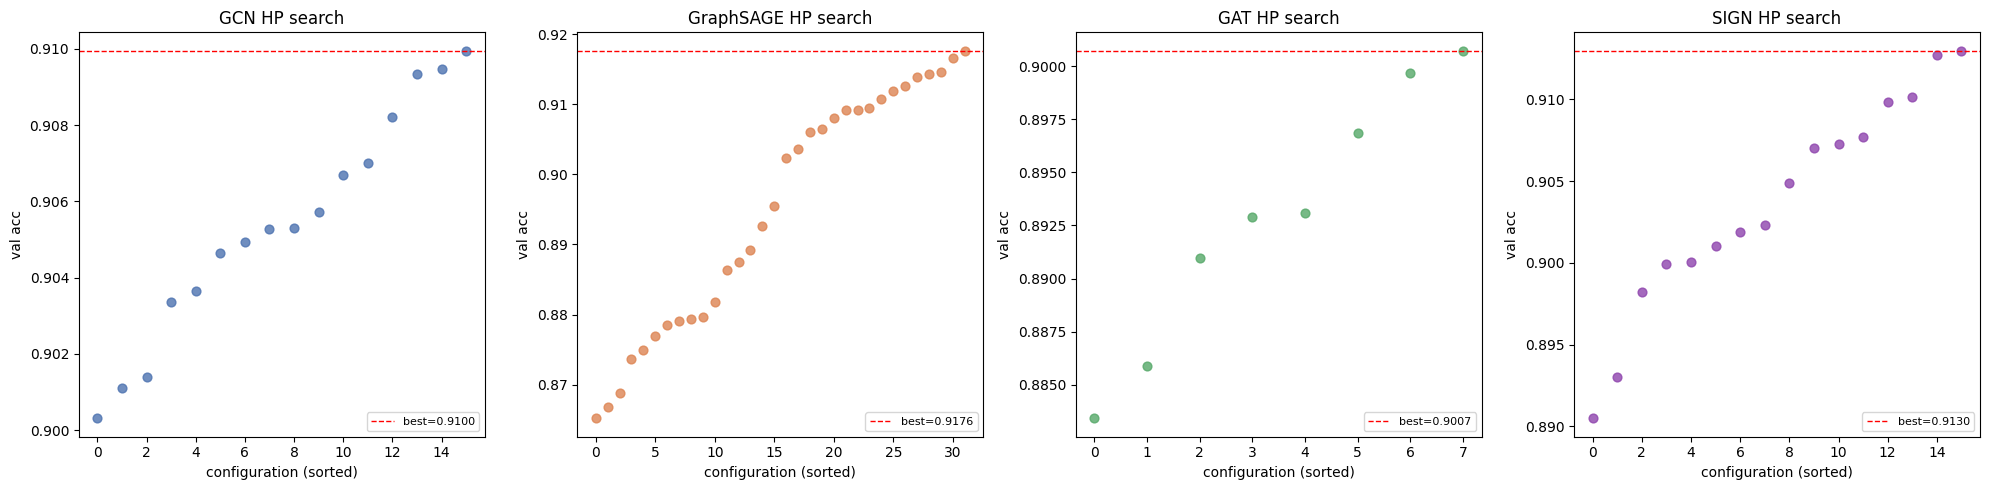

Saved: plots/hp_search_scatter.png


In [24]:
df_all = pd.DataFrame(all_results)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
model_names = ['GCN', 'GraphSAGE', 'GAT', 'SIGN']
dfs = [df_gcn, df_sage, df_gat, df_sign]
colors_list = ['#4C72B0', '#DD8452', '#55A868', '#8E44AD']

for ax, df_m, mname, col in zip(axes, dfs, model_names, colors_list):
    vals = df_m['val_acc'].values
    ax.scatter(range(len(vals)), sorted(vals), color=col, s=40, alpha=0.8)
    ax.axhline(vals.max(), color='red', linestyle='--', linewidth=1, label=f'best={vals.max():.4f}')
    ax.set_xlabel('configuration (sorted)')
    ax.set_ylabel('val acc')
    ax.set_title(f'{mname} HP search')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('plots/hp_search_scatter_sign.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plots/hp_search_scatter.png')

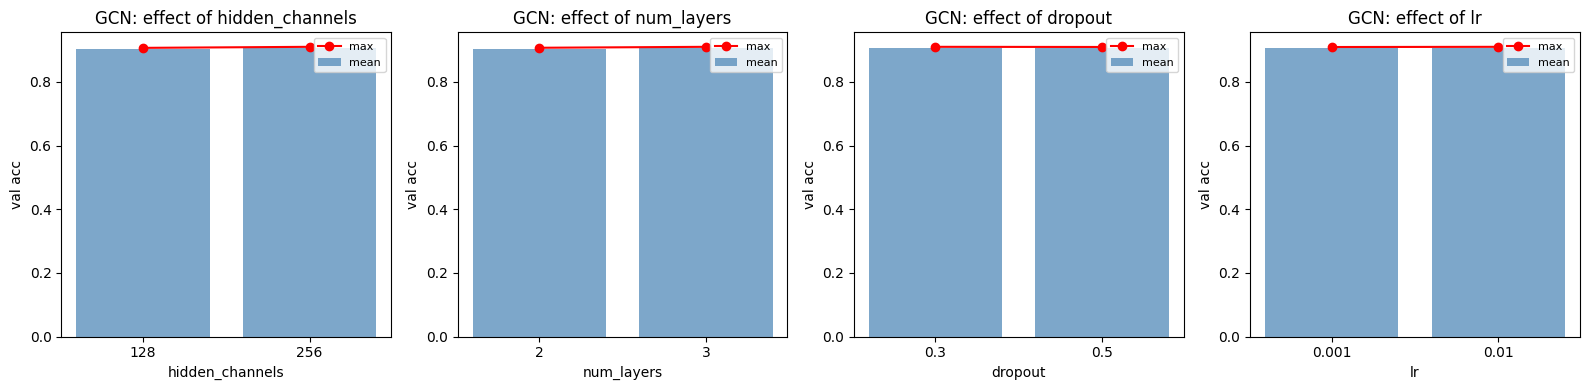

Saved: plots/gcn_hp_effect.png


In [25]:
# Effect of individual hyperparameters on val acc (GCN)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, hp in zip(axes, ['hidden_channels', 'num_layers', 'dropout', 'lr']):
    grp = df_gcn.groupby(hp)['val_acc'].agg(['mean', 'max'])
    ax.bar([str(x) for x in grp.index], grp['mean'], alpha=0.7, color='steelblue', label='mean')
    ax.plot([str(x) for x in grp.index], grp['max'], 'ro-', markersize=6, label='max')
    ax.set_xlabel(hp)
    ax.set_ylabel('val acc')
    ax.set_title(f'GCN: effect of {hp}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('plots/gcn_hp_effect.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plots/gcn_hp_effect.png')

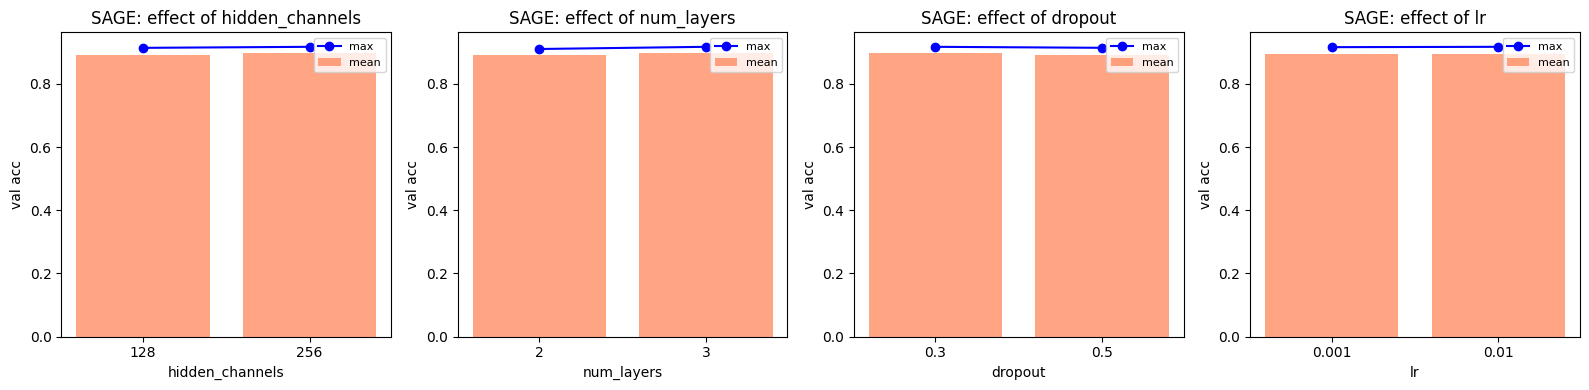

Saved: plots/sage_hp_effect.png


In [26]:
# Effect of individual hyperparameters on val acc (GraphSAGE)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, hp in zip(axes, ['hidden_channels', 'num_layers', 'dropout', 'lr']):
    grp = df_sage.groupby(hp)['val_acc'].agg(['mean', 'max'])
    ax.bar([str(x) for x in grp.index], grp['mean'], alpha=0.7, color='coral', label='mean')
    ax.plot([str(x) for x in grp.index], grp['max'], 'bo-', markersize=6, label='max')
    ax.set_xlabel(hp)
    ax.set_ylabel('val acc')
    ax.set_title(f'SAGE: effect of {hp}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('plots/sage_hp_effect.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plots/sage_hp_effect.png')

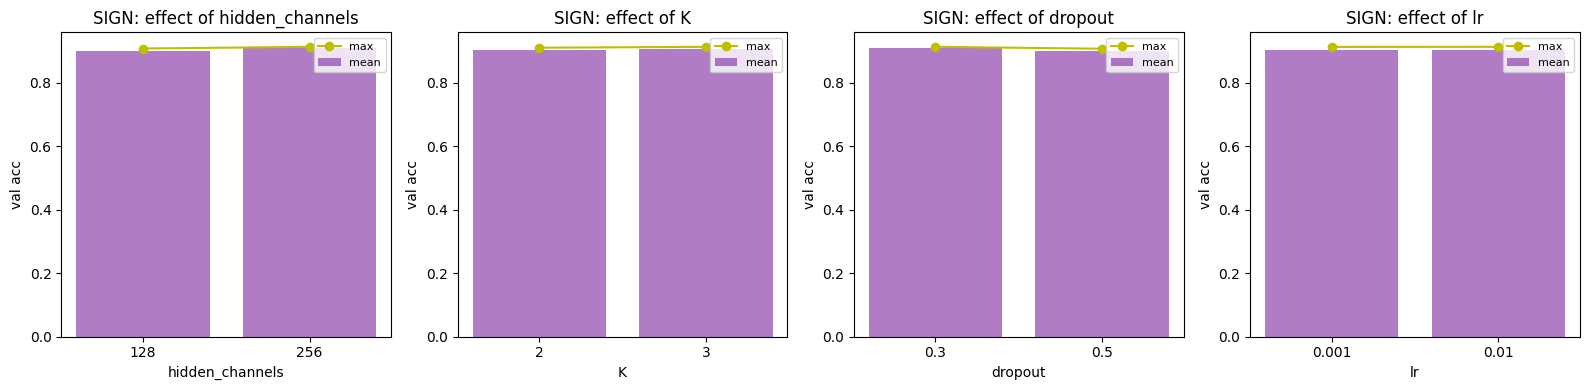

Saved: plots/sign_hp_effect.png


In [27]:
# Effect of individual hyperparameters on val acc (SIGN)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, hp in zip(axes, ['hidden_channels', 'K', 'dropout', 'lr']):
    grp = df_sign.groupby(hp)['val_acc'].agg(['mean', 'max'])
    ax.bar([str(x) for x in grp.index], grp['mean'], alpha=0.7, color='#8E44AD', label='mean')
    ax.plot([str(x) for x in grp.index], grp['max'], 'yo-', markersize=6, label='max')
    ax.set_xlabel(hp)
    ax.set_ylabel('val acc')
    ax.set_title(f'SIGN: effect of {hp}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('plots/sign_hp_effect.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plots/sign_hp_effect.png')

## 7. Full Training of Best Configurations

We pick the best hyperparameter configuration for each model and train for the full number of epochs with early stopping.

In [28]:
# Extract best configs
best_gcn_row  = df_gcn.iloc[0]
best_sage_row = df_sage.iloc[0]
best_gat_row  = df_gat.iloc[0]

print('Best GCN config:')
print(best_gcn_row.to_dict())
print('\nBest GraphSAGE config:')
print(best_sage_row.to_dict())
print('\nBest GAT config:')
print(best_gat_row.to_dict())

Best GCN config:
{'model': 'GCN', 'val_acc': 0.90995091930931, 'hidden_channels': 256, 'num_layers': 3, 'dropout': 0.3, 'lr': 0.01, 'weight_decay': 0.0}

Best GraphSAGE config:
{'model': 'GraphSAGE', 'val_acc': 0.9176309030338479, 'hidden_channels': 256, 'num_layers': 3, 'dropout': 0.3, 'lr': 0.01, 'aggr': 'mean', 'weight_decay': 0.0}

Best GAT config:
{'model': 'GAT', 'val_acc': 0.9007196805940544, 'hidden_channels': 64, 'num_layers': 3, 'heads': 4, 'dropout': 0.3, 'lr': 0.005, 'weight_decay': 0.0}


In [29]:
# --- Train best GCN ---
print('Training best GCN...')
gcn_kwargs = {
    'in_channels':     IN_CHANNELS,
    'hidden_channels': int(best_gcn_row['hidden_channels']),
    'out_channels':    NUM_CLASSES,
    'num_layers':      int(best_gcn_row['num_layers']),
    'dropout':         float(best_gcn_row['dropout']),
}
final_gcn_ckpt = f'checkpoints/final_GCN.pt'
if os.path.exists(final_gcn_ckpt):
    print('Loading existing GCN final checkpoint...')
    ckpt = torch.load(final_gcn_ckpt, map_location=DEVICE)
    best_gcn_model = GCN(**gcn_kwargs).to(DEVICE)
    best_gcn_model.load_state_dict(ckpt['model_state'])
    gcn_val_acc = ckpt['val_acc']
    gcn_history = ckpt.get('history', {'train_loss': [], 'val_acc': []})
    print(f'GCN loaded, best val acc: {gcn_val_acc:.4f}')
else:
    best_gcn_model, gcn_history, gcn_val_acc = train_model(
        GCN, gcn_kwargs, 'GCN', train_loader, val_loader,
        lr=float(best_gcn_row['lr']), weight_decay=0.0,
        epochs=FINAL_EPOCHS, device=DEVICE, evaluator=evaluator,
        patience=PATIENCE, checkpoint_prefix='final'
    )
    print(f'GCN best val acc: {gcn_val_acc:.4f}')

Training best GCN...
Loading existing GCN final checkpoint...
GCN loaded, best val acc: 0.9163


In [30]:
# --- Train best GraphSAGE ---
print('Training best GraphSAGE...')
sage_kwargs = {
    'in_channels':     IN_CHANNELS,
    'hidden_channels': int(best_sage_row['hidden_channels']),
    'out_channels':    NUM_CLASSES,
    'num_layers':      int(best_sage_row['num_layers']),
    'dropout':         float(best_sage_row['dropout']),
    'aggr':            str(best_sage_row['aggr']),
}
final_sage_ckpt = f'checkpoints/final_GraphSAGE.pt'
if os.path.exists(final_sage_ckpt):
    print('Loading existing GraphSAGE final checkpoint...')
    ckpt = torch.load(final_sage_ckpt, map_location=DEVICE)
    best_sage_model = GraphSAGE(**sage_kwargs).to(DEVICE)
    best_sage_model.load_state_dict(ckpt['model_state'])
    sage_val_acc = ckpt['val_acc']
    sage_history = ckpt.get('history', {'train_loss': [], 'val_acc': []})
    print(f'GraphSAGE loaded, best val acc: {sage_val_acc:.4f}')
else:
    best_sage_model, sage_history, sage_val_acc = train_model(
        GraphSAGE, sage_kwargs, 'GraphSAGE', train_loader, val_loader,
        lr=float(best_sage_row['lr']), weight_decay=0.0,
        epochs=FINAL_EPOCHS, device=DEVICE, evaluator=evaluator,
        patience=PATIENCE, checkpoint_prefix='final'
    )
    print(f'GraphSAGE best val acc: {sage_val_acc:.4f}')

Training best GraphSAGE...
Loading existing GraphSAGE final checkpoint...
GraphSAGE loaded, best val acc: 0.9211


In [31]:
# --- Train best GAT ---
print('Training best GAT...')
gat_kwargs = {
    'in_channels':     IN_CHANNELS,
    'hidden_channels': int(best_gat_row['hidden_channels']),
    'out_channels':    NUM_CLASSES,
    'num_layers':      int(best_gat_row['num_layers']),
    'heads':           int(best_gat_row['heads']),
    'dropout':         float(best_gat_row['dropout']),
}
final_gat_ckpt = f'checkpoints/final_GAT.pt'
if os.path.exists(final_gat_ckpt):
    print('Loading existing GAT final checkpoint...')
    ckpt = torch.load(final_gat_ckpt, map_location=DEVICE)
    best_gat_model = GAT(**gat_kwargs).to(DEVICE)
    best_gat_model.load_state_dict(ckpt['model_state'])
    gat_val_acc = ckpt['val_acc']
    gat_history = ckpt.get('history', {'train_loss': [], 'val_acc': []})
    print(f'GAT loaded, best val acc: {gat_val_acc:.4f}')
else:
    best_gat_model, gat_history, gat_val_acc = train_model(
        GAT, gat_kwargs, 'GAT', train_loader, val_loader,
        lr=float(best_gat_row['lr']), weight_decay=0.0,
        epochs=FINAL_EPOCHS, device=DEVICE, evaluator=evaluator,
        patience=PATIENCE, checkpoint_prefix='final'
    )
    print(f'GAT best val acc: {gat_val_acc:.4f}')

Training best GAT...
Loading existing GAT final checkpoint...
GAT loaded, best val acc: 0.9048


### SIGN full training

In [32]:
# Ensure data_y for SIGN
if 'data_y' not in dir():
    from ogb.nodeproppred import PygNodePropPredDataset
    print('Loading data_y from dataset...')
    ds = dataset if 'dataset' in dir() else PygNodePropPredDataset(name='ogbn-products', root='data')
    data_y = ds[0].y.to('cpu')

if not sign_features_ready or df_sign.empty:
    print('Skipping SIGN full training (no SIGN features or no HP results).')
else:
    # --- Train best SIGN ---
    print('Training best SIGN...')
    best_sign_row = df_sign.iloc[0]
    sign_kwargs = {
        'in_channels':     IN_CHANNELS,
        'hidden_channels': int(best_sign_row['hidden_channels']),
        'out_channels':    NUM_CLASSES,
        'K':               int(best_sign_row['K']),
        'dropout':         float(best_sign_row['dropout']),
    }
    K_best = sign_kwargs['K']

    final_sign_ckpt = 'checkpoints/final_SIGN.pt'
    sign_history = {'train_loss': [], 'val_acc': []}
    if os.path.exists(final_sign_ckpt):
        print('Loading existing SIGN final checkpoint...')
        ckpt = torch.load(final_sign_ckpt, map_location=DEVICE)
        best_sign_model = SIGNModel(**sign_kwargs).to(DEVICE)
        best_sign_model.load_state_dict(ckpt['model_state'])
        sign_val_acc = ckpt['val_acc']
        sign_history = ckpt.get('history', {'train_loss': [], 'val_acc': []})
        print(f'SIGN loaded, best val acc: {sign_val_acc:.4f}')
    else:
        best_sign_model = SIGNModel(**sign_kwargs).to(DEVICE)
        optimizer = torch.optim.Adam(best_sign_model.parameters(),
                                     lr=float(best_sign_row['lr']))
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=5
        )

        best_val_acc = 0.0
        patience_count = 0
        print(f'      ', end='')
        for epoch in range(1, FINAL_EPOCHS + 1):
            t0 = time.time()
            loss = train_epoch_sign(best_sign_model, xs_full[:K_best+1],
                                     train_idx, optimizer, DEVICE)
            val_acc, _, _ = evaluate_sign(best_sign_model, xs_full[:K_best+1],
                                            valid_idx, DEVICE)
            scheduler.step(val_acc)

            sign_history['train_loss'].append(loss)
            sign_history['val_acc'].append(val_acc)
            print('|', end='', flush=True)

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                patience_count = 0
                torch.save({
                    'epoch': epoch,
                    'model_state': best_sign_model.state_dict(),
                    'val_acc': val_acc,
                    'model_kwargs': sign_kwargs,
                    'history': sign_history,
                }, final_sign_ckpt)
            else:
                patience_count += 1

            if epoch % 5 == 0:
                print(f'  Epoch {epoch:3d} | loss {loss:.4f} | val acc {val_acc:.4f} '
                      f'| best {best_val_acc:.4f} | {time.time()-t0:.1f}s')

            if patience_count >= PATIENCE:
                print(f'  Early stopping at epoch {epoch}')
                break

        print()
        ckpt = torch.load(final_sign_ckpt, map_location=DEVICE)
        best_sign_model.load_state_dict(ckpt['model_state'])
        sign_val_acc = best_val_acc
        print(f'  Best val acc: {sign_val_acc:.4f}')

    print(f'SIGN best val acc: {sign_val_acc:.4f}')

Training best SIGN...
Loading existing SIGN final checkpoint...
SIGN loaded, best val acc: 0.9120
SIGN best val acc: 0.9120


## 8. Training Curves

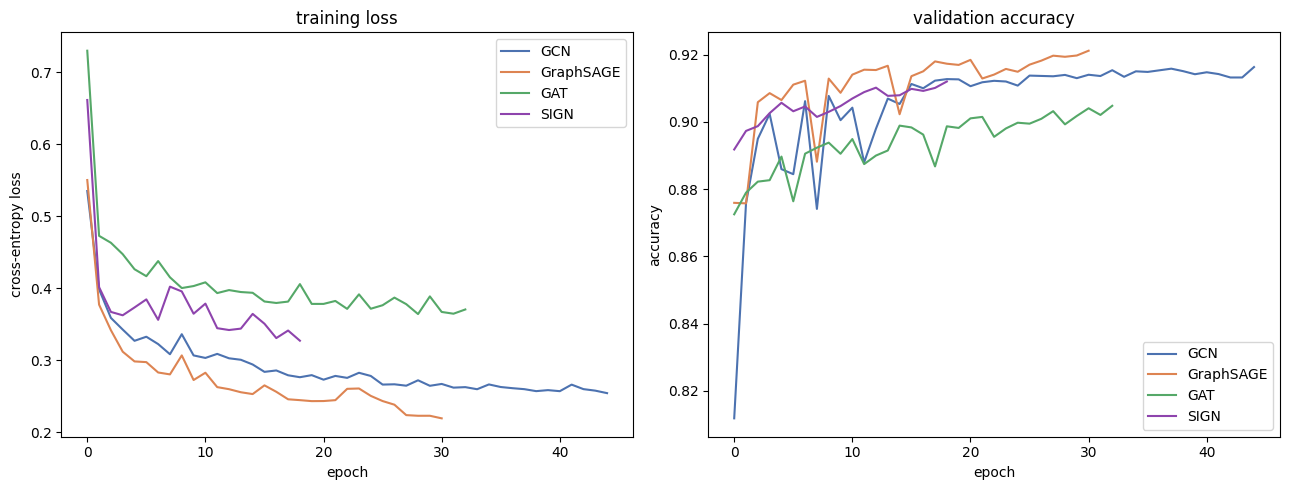

Saved: plots/training_curves.png


In [33]:
loaded_histories = load_comparison_data('histories')
if loaded_histories is not None and 'gcn_history' not in locals():
    gcn_history  = loaded_histories.get('GCN', {'train_loss': [], 'val_acc': []})
    sage_history = loaded_histories.get('GraphSAGE', {'train_loss': [], 'val_acc': []})
    gat_history  = loaded_histories.get('GAT', {'train_loss': [], 'val_acc': []})
    sign_history = loaded_histories.get('SIGN', {'train_loss': [], 'val_acc': []}) if 'sign_features_ready' not in globals() or sign_features_ready else {'train_loss': [], 'val_acc': []}

histories = {
    'GCN':        gcn_history,
    'GraphSAGE':  sage_history,
    'GAT':        gat_history,
    'SIGN':       sign_history if 'sign_features_ready' not in globals() or sign_features_ready else {'train_loss': [], 'val_acc': []},
}
save_comparison_data('histories', histories)

model_colors = {'GCN': '#4C72B0', 'GraphSAGE': '#DD8452', 'GAT': '#55A868', 'SIGN': '#8E44AD'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for mname, hist in histories.items():
    axes[0].plot(hist['train_loss'], label=mname, color=model_colors[mname])
    axes[1].plot(hist['val_acc'],    label=mname, color=model_colors[mname])

axes[0].set_xlabel('epoch')
axes[0].set_ylabel('cross-entropy loss')
axes[0].set_title('training loss')
axes[0].legend()

axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].set_title('validation accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plots/training_curves.png')

## 9. Test Evaluation

In [34]:
results_final = load_comparison_data('results_final', DEVICE)
# Ensure data_y for SIGN
if 'data_y' not in dir():
    from ogb.nodeproppred import PygNodePropPredDataset
    print('Loading data_y from dataset...')
    ds = dataset if 'dataset' in dir() else PygNodePropPredDataset(name='ogbn-products', root='data')
    data_y = ds[0].y.to('cpu')

models_to_eval = [('GCN', best_gcn_model), ('GraphSAGE', best_sage_model),
                   ('GAT', best_gat_model), ('SIGN', best_sign_model)]

if results_final is None:
    results_final = {}
else:
    for mname, res in results_final.items():
        print(f'{mname:12s} | val acc {res["val_acc"]:.4f} | test acc {res["test_acc"]:.4f}')

for mname, model in models_to_eval:
    if mname in results_final:
        continue
    print(f'  {mname} not in cache, evaluating...')
    if mname == 'SIGN':
        val_acc, val_true, val_pred = evaluate_sign(
            model, xs_full[:K_best+1], valid_idx, DEVICE)
        tst_acc, tst_true, tst_pred = evaluate_sign(
            model, xs_full[:K_best+1], test_idx, DEVICE)
    else:
        val_acc, val_true, val_pred = evaluate(model, val_loader,  evaluator, DEVICE)
        tst_acc, tst_true, tst_pred = evaluate(model, test_loader, evaluator, DEVICE)
    results_final[mname] = {
        'val_acc':  val_acc,
        'test_acc': tst_acc,
        'y_true':   tst_true,
        'y_pred':   tst_pred,
    }
    print(f'{mname:12s} | val acc {val_acc:.4f} | test acc {tst_acc:.4f}')
save_comparison_data('results_final', results_final)


GCN          | val acc 0.9143 | test acc 0.7802
GraphSAGE    | val acc 0.9198 | test acc 0.7878
GAT          | val acc 0.9036 | test acc 0.7819
  SIGN not in cache, evaluating...
SIGN         | val acc 0.9120 | test acc 0.7371


### Model comparison

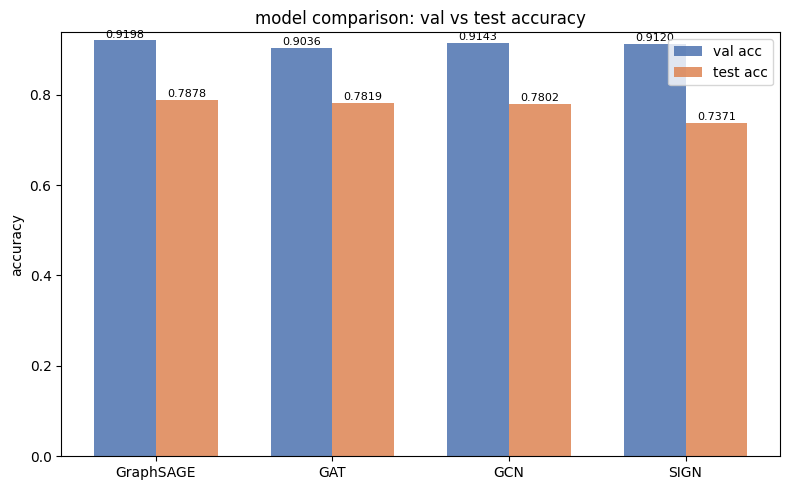

Saved: plots/model_comparison.png
    model  val_acc  test_acc
GraphSAGE 0.919843  0.787769
      GAT 0.903619  0.781921
      GCN 0.914274  0.780187
     SIGN 0.911985  0.737121


In [35]:
if 'results_final' not in locals() or results_final is None:
    results_final = load_comparison_data('results_final', DEVICE) or {}

comp_df = pd.DataFrame({
    'model':    list(results_final.keys()),
    'val_acc':  [v['val_acc']  for v in results_final.values()],
    'test_acc': [v['test_acc'] for v in results_final.values()],
})
comp_df = comp_df.sort_values('test_acc', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(comp_df))
width = 0.35
bars1 = ax.bar(x - width/2, comp_df['val_acc'],  width, label='val acc',  color='#4C72B0', alpha=0.85)
bars2 = ax.bar(x + width/2, comp_df['test_acc'], width, label='test acc', color='#DD8452', alpha=0.85)

for bar in bars1 + bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.002, f'{h:.4f}',
            ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(comp_df['model'])
ax.set_ylabel('accuracy')
ax.set_ylim(0, min(1.0, comp_df['test_acc'].max() + 0.15))
ax.set_title('model comparison: val vs test accuracy')
ax.legend()

plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plots/model_comparison.png')
print(comp_df.to_string(index=False))

### Confusion matrices

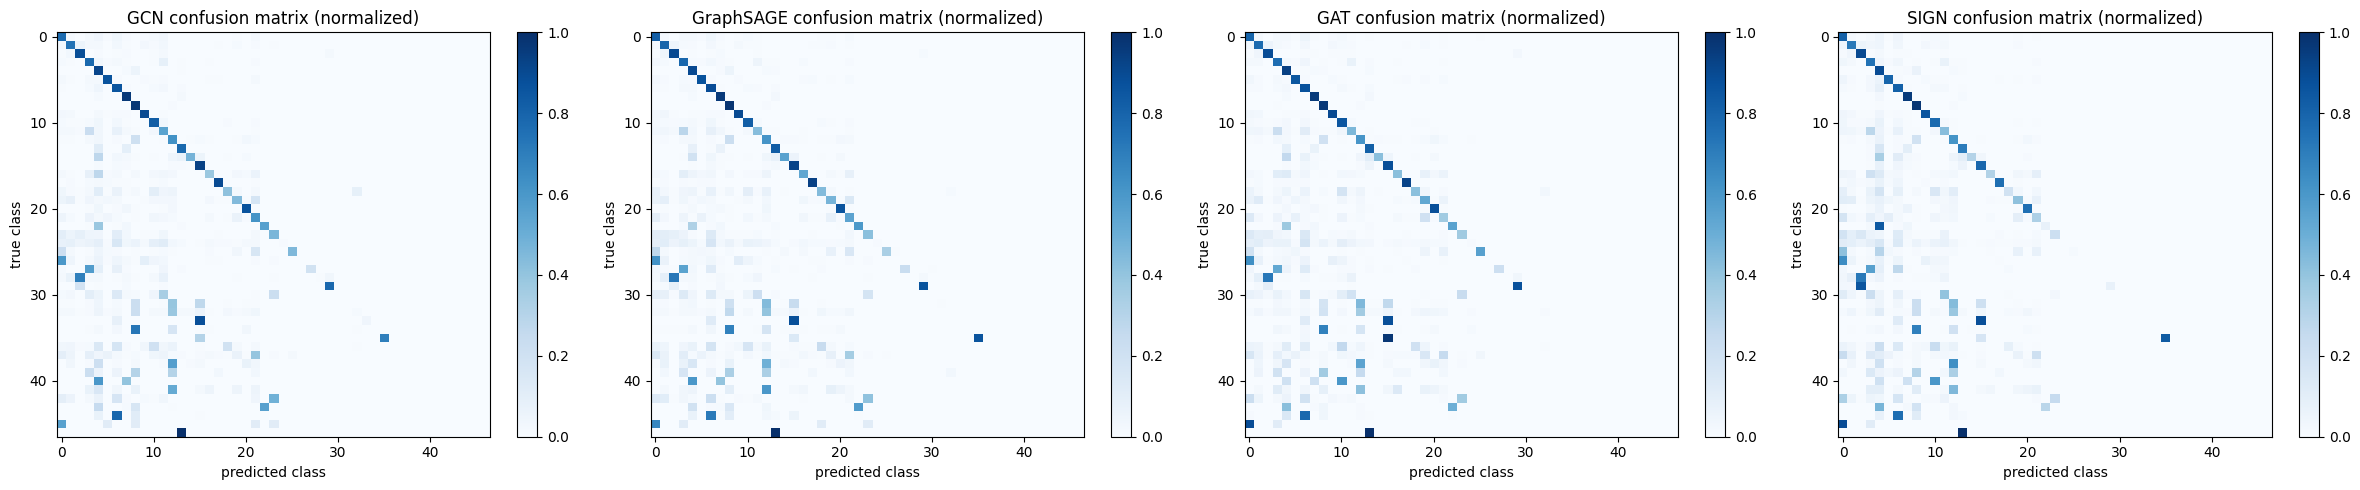

Saved: plots/confusion_matrices.png


In [36]:
n_cm = len(results_final)
fig, axes = plt.subplots(1, n_cm, figsize=(6 * n_cm, 5))
if n_cm == 1:
    axes = [axes]

for ax, (mname, res) in zip(axes, results_final.items()):
    y_t = res['y_true'].cpu().numpy().flatten()
    y_p = res['y_pred'].cpu().numpy().flatten()
    cm = confusion_matrix(y_t, y_p)
    # Normalize
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
    im = ax.imshow(cm_norm, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    ax.set_title(f'{mname} confusion matrix (normalized)')
    ax.set_xlabel('predicted class')
    ax.set_ylabel('true class')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('plots/confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plots/confusion_matrices.png')


### Per-class accuracy

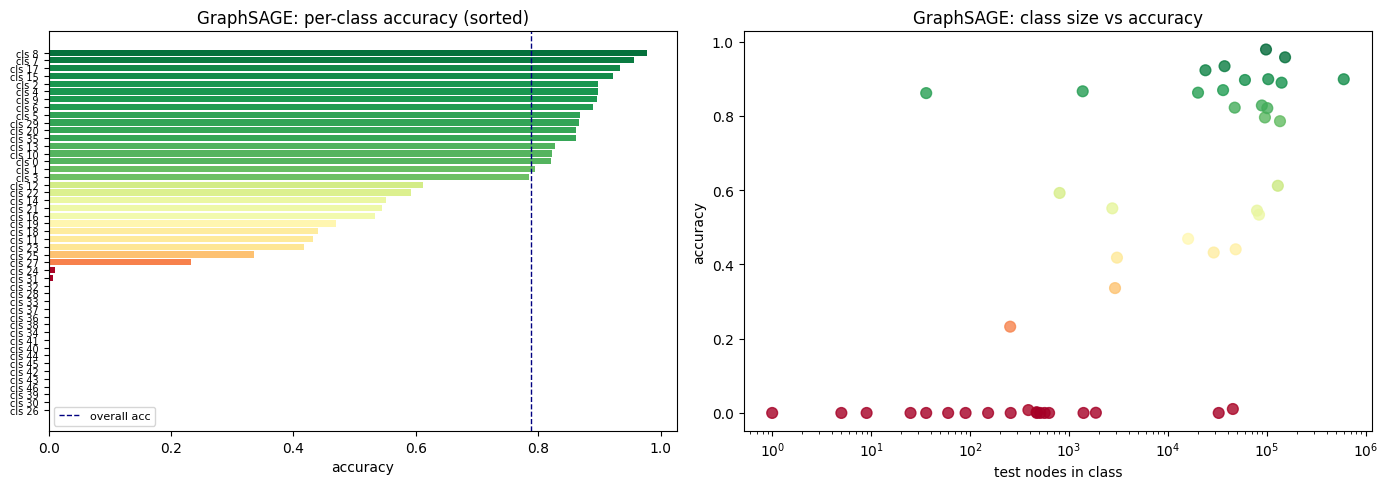

Saved: plots/per_class_accuracy.png


In [37]:
# Use the best model (by test acc) for per-class analysis
best_model_name = comp_df.iloc[0]['model']
best_res = results_final[best_model_name]
y_t = best_res['y_true'].cpu().numpy().flatten()
y_p = best_res['y_pred'].cpu().numpy().flatten()

per_class_acc = []
for cls in range(NUM_CLASSES):
    mask = y_t == cls
    if mask.sum() > 0:
        acc_cls = (y_p[mask] == y_t[mask]).mean()
        per_class_acc.append({'class': cls, 'acc': acc_cls, 'count': mask.sum()})

df_per_class = pd.DataFrame(per_class_acc).sort_values('acc', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-class accuracy bar
axes[0].barh(range(len(df_per_class)), df_per_class['acc'],
             color=[plt.cm.RdYlGn(a) for a in df_per_class['acc']])
axes[0].set_yticks(range(len(df_per_class)))
axes[0].set_yticklabels([f'cls {int(r)}' for r in df_per_class['class']], fontsize=7)
axes[0].set_xlabel('accuracy')
axes[0].set_title(f'{best_model_name}: per-class accuracy (sorted)')
axes[0].axvline(y_t.shape[0] and (y_p == y_t).mean(), color='navy',
                linestyle='--', linewidth=1, label='overall acc')
axes[0].legend(fontsize=8)

# Accuracy vs class size scatter
axes[1].scatter(df_per_class['count'], df_per_class['acc'],
                c=df_per_class['acc'], cmap='RdYlGn', s=60, alpha=0.8)
axes[1].set_xlabel('test nodes in class')
axes[1].set_ylabel('accuracy')
axes[1].set_xscale('log')
axes[1].set_title(f'{best_model_name}: class size vs accuracy')

plt.tight_layout()
plt.savefig('plots/per_class_accuracy.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plots/per_class_accuracy.png')


Larger classes (more test samples) tend to have higher accuracy, which is expected given more training examples and the time-based split strategy of OGB.

## 10. Embedding Visualization (t-SNE)

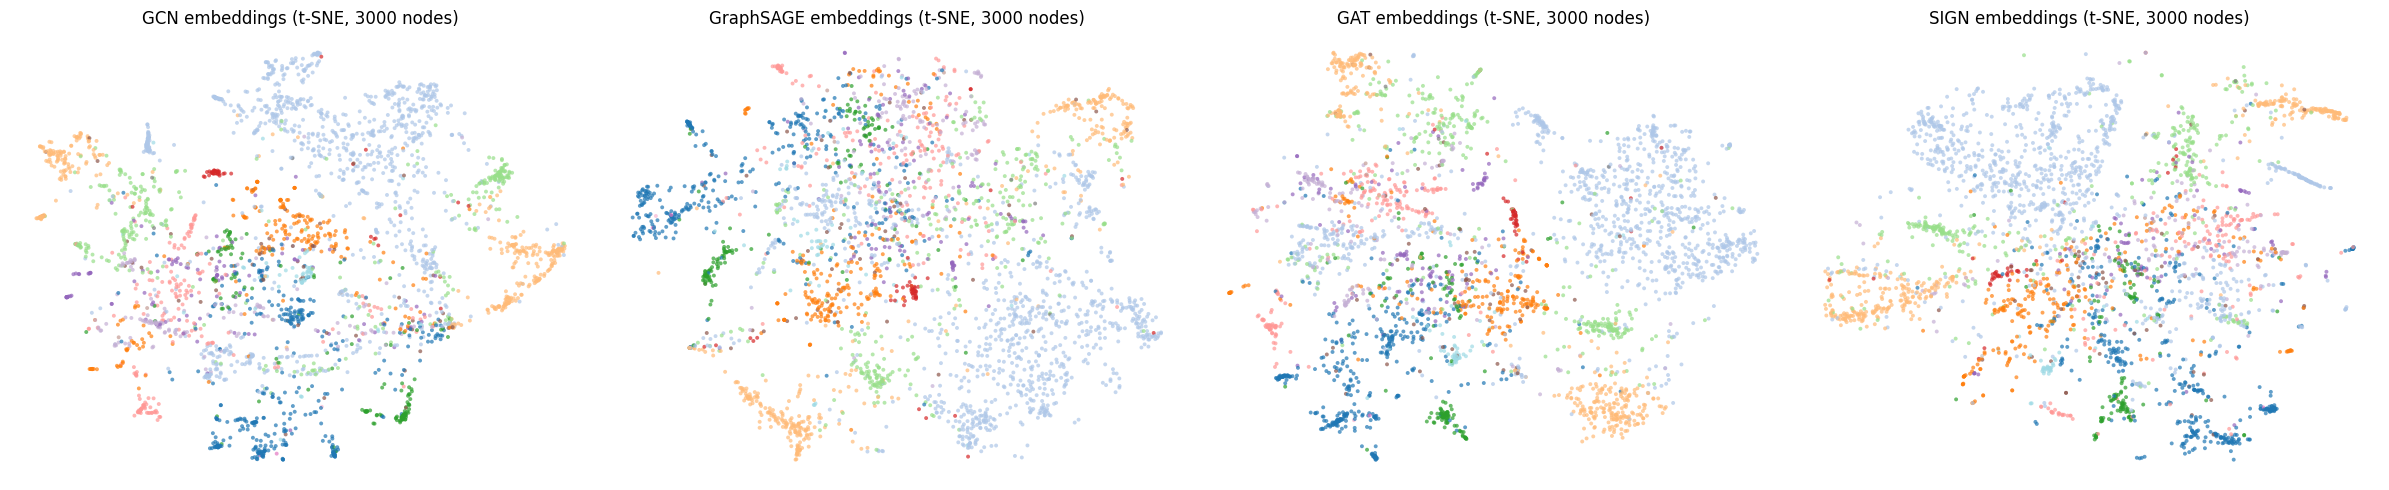

Saved: plots/tsne_embeddings.png


In [39]:
# Extract embeddings from a sample of test nodes
EMBED_SAMPLE = 3000

n_tsne = 4 if 'sign_features_ready' in globals() and sign_features_ready else 3
fig, axes = plt.subplots(1, n_tsne, figsize=(6 * n_tsne, 5))

tsne_models = [('GCN', best_gcn_model), ('GraphSAGE', best_sage_model),
                           ('GAT', best_gat_model)]
if 'sign_features_ready' in globals() and sign_features_ready:
    tsne_models.append(('SIGN', best_sign_model))
for ax, (mname, model) in zip(axes, tsne_models):
    model.eval()
    emb_list = []
    label_list = []
    collected = 0

    with torch.no_grad():
        if mname == 'SIGN':
            # SIGN: iterate over test_idx directly using precomputed features
            idx = test_idx.to(DEVICE)
            perm = torch.randperm(len(idx))[:EMBED_SAMPLE]
            batch_nodes = idx[perm].cpu()
            xs_batch = [x[batch_nodes].to(DEVICE) for x in xs_full[:K_best+1]]
            emb = model.get_embeddings(xs_batch).cpu()
            labels_embed = data.y[batch_nodes].cpu().numpy().flatten()
            z2d = TSNE(n_components=2, perplexity=40, max_iter=300, random_state=SEED).fit_transform(emb.numpy())
            sc = ax.scatter(z2d[:, 0], z2d[:, 1], c=labels_embed,
                            cmap='tab20', s=8, alpha=0.7, linewidths=0)
            ax.set_title(f'{mname} embeddings (t-SNE, {EMBED_SAMPLE} nodes)')
            ax.axis('off')
            continue
        for batch in test_loader:
            batch = batch.to(DEVICE)
            n = batch.batch_size
            emb = model.get_embeddings(batch.x, batch.edge_index)[:n].cpu()
            emb_list.append(emb)
            label_list.append(batch.y[:n].cpu())
            collected += n
            if collected >= EMBED_SAMPLE:
                break

        embs   = torch.cat(emb_list, dim=0)[:EMBED_SAMPLE].numpy()
        labels_embed = torch.cat(label_list, dim=0)[:EMBED_SAMPLE].numpy().flatten()

        z2d  = TSNE(n_components=2, perplexity=40, max_iter=300, random_state=SEED).fit_transform(embs)

        sc = ax.scatter(z2d[:, 0], z2d[:, 1], c=labels_embed,
                        cmap='tab20', s=8, alpha=0.7, linewidths=0)
        ax.set_title(f'{mname} embeddings (t-SNE, {EMBED_SAMPLE} nodes)')
        ax.axis('off')

plt.tight_layout()
plt.savefig('plots/tsne_embeddings.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plots/tsne_embeddings.png')

Distinct clusters in the t-SNE plot indicate that the learned node embeddings are class-discriminative. Better-separated clusters correlate with higher test accuracy.

## 11. Hyperparameter Search Summary Heatmaps

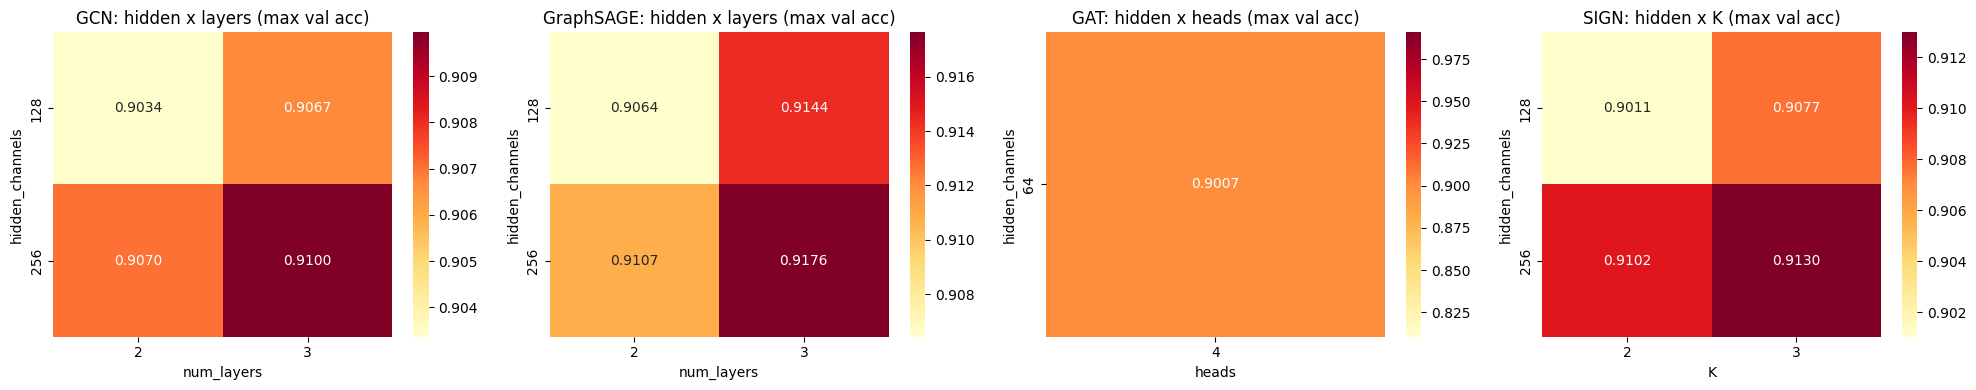

Saved: plots/hp_heatmaps.png


In [40]:
# Pivot table: hidden_channels vs num_layers for GCN
pivot_gcn = df_gcn.groupby(['hidden_channels', 'num_layers'])['val_acc'].max().unstack()

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# GCN: hidden x layers
sns.heatmap(pivot_gcn, annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('GCN: hidden x layers (max val acc)')
axes[0].set_xlabel('num_layers')
axes[0].set_ylabel('hidden_channels')

# SAGE: hidden x layers
pivot_sage = df_sage.groupby(['hidden_channels', 'num_layers'])['val_acc'].max().unstack()
sns.heatmap(pivot_sage, annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('GraphSAGE: hidden x layers (max val acc)')
axes[1].set_xlabel('num_layers')
axes[1].set_ylabel('hidden_channels')

# GAT: hidden x heads
pivot_gat = df_gat.groupby(['hidden_channels', 'heads'])['val_acc'].max().unstack()
sns.heatmap(pivot_gat, annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[2])
axes[2].set_title('GAT: hidden x heads (max val acc)')
axes[2].set_xlabel('heads')
axes[2].set_ylabel('hidden_channels')

# SIGN: hidden x K
pivot_sign = df_sign.groupby(['hidden_channels', 'K'])['val_acc'].max().unstack()
sns.heatmap(pivot_sign, annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[3])
axes[3].set_title('SIGN: hidden x K (max val acc)')
axes[3].set_xlabel('K')
axes[3].set_ylabel('hidden_channels')

plt.tight_layout()
plt.savefig('plots/hp_heatmaps.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plots/hp_heatmaps.png')

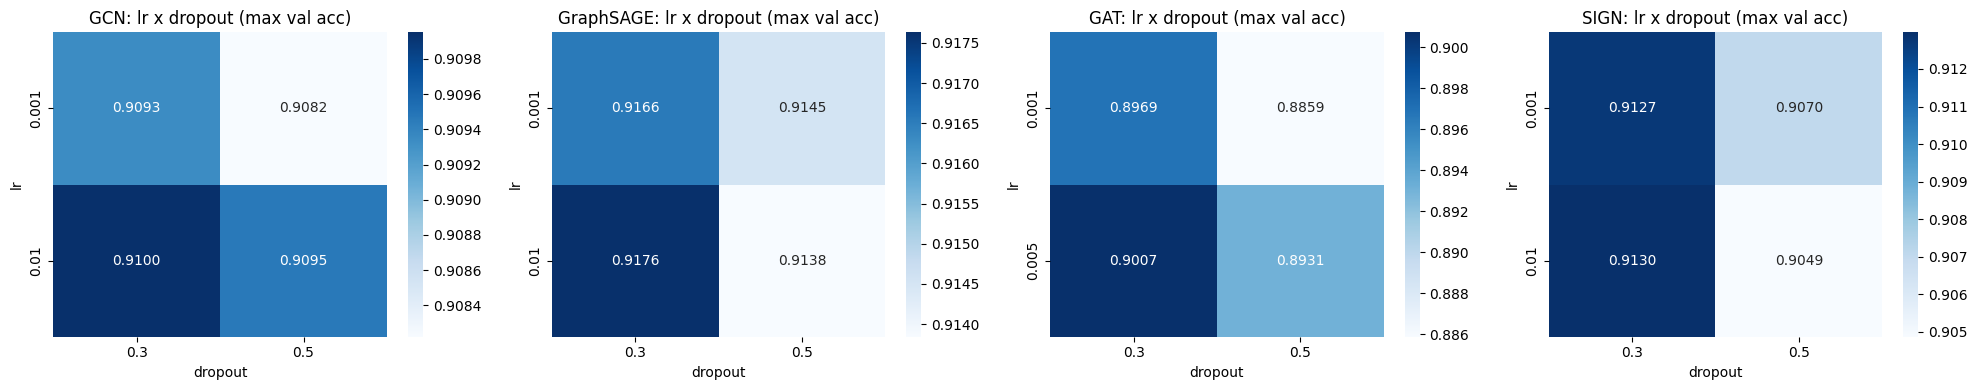

Saved: plots/lr_dropout_heatmaps.png


In [41]:
# Learning rate vs dropout heatmap for all models
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
pairs = [('GCN', df_gcn), ('GraphSAGE', df_sage), ('GAT', df_gat), ('SIGN', df_sign)]

for ax, (mname, df_m) in zip(axes, pairs):
    pivot = df_m.groupby(['lr', 'dropout'])['val_acc'].max().unstack()
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='Blues', ax=ax)
    ax.set_title(f'{mname}: lr x dropout (max val acc)')
    ax.set_xlabel('dropout')
    ax.set_ylabel('lr')

plt.tight_layout()
plt.savefig('plots/lr_dropout_heatmaps.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plots/lr_dropout_heatmaps.png')

## 12. Summary Table and Final Comparison

In [43]:
summary_rows = []
for mname, res in results_final.items():
    y_t = res['y_true'].cpu().numpy().flatten()
    y_p = res['y_pred'].cpu().numpy().flatten()
    from sklearn.metrics import f1_score
    f1_macro  = f1_score(y_t, y_p, average='macro',  zero_division=0)
    f1_weighted = f1_score(y_t, y_p, average='weighted', zero_division=0)
    summary_rows.append({
        'model':        mname,
        'val_acc':      round(res['val_acc'],  4),
        'test_acc':     round(res['test_acc'], 4),
        'f1_macro':     round(f1_macro,  4),
        'f1_weighted':  round(f1_weighted, 4),
    })

df_summary = pd.DataFrame(summary_rows).sort_values('test_acc', ascending=False)
print('=== Final results ===')
print(df_summary.to_string(index=False))

# Save to CSV
df_summary.to_csv('checkpoints/final_results.csv', index=False)
print('Saved: checkpoints/final_results.csv')

=== Final results ===
    model  val_acc  test_acc  f1_macro  f1_weighted
GraphSAGE   0.9198    0.7878    0.3972       0.7741
      GAT   0.9036    0.7819    0.3662       0.7668
      GCN   0.9143    0.7802    0.3933       0.7667
     SIGN   0.9120    0.7371    0.3321       0.7152
Saved: checkpoints/final_results.csv


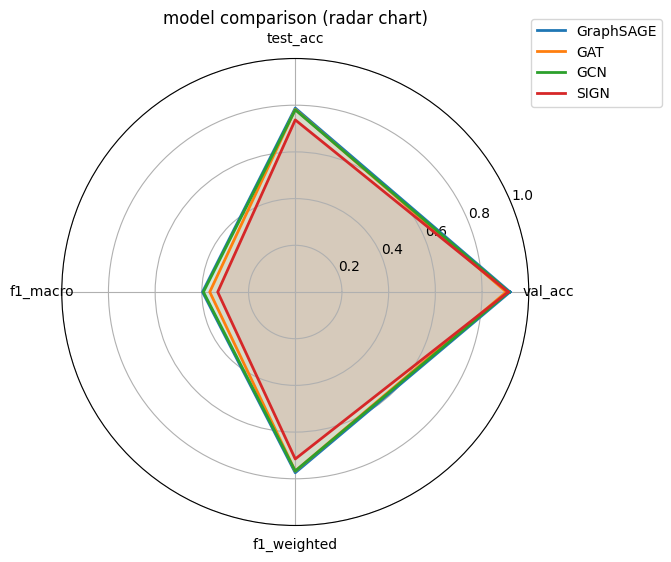

Saved: plots/radar_chart.png


In [44]:
# Radar / spider chart of metrics
from matplotlib.patches import FancyArrowPatch

metrics_cols = ['val_acc', 'test_acc', 'f1_macro', 'f1_weighted']
n_metrics = len(metrics_cols)
angles = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for idx, row in df_summary.iterrows():
    vals = [row[m] for m in metrics_cols]
    vals += vals[:1]
    ax.plot(angles, vals, label=row['model'], linewidth=2)
    ax.fill(angles, vals, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_cols)
ax.set_ylim(0, 1)
ax.set_title('model comparison (radar chart)')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('plots/radar_chart.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: plots/radar_chart.png')

## 13. Conclusions

### Dataset
ogbn-products is a large-scale real-world graph with 2.4M nodes and 61M edges. The class distribution is heavily imbalanced (power law), and the temporal split makes generalization harder than a random split.

### Model observations

**GCN:** Simple and fast. Symmetric normalization can disadvantage high-degree nodes (hubs get their signals diluted). Works well as a baseline with 2-3 layers.

**GraphSAGE:** Generally the strongest model on ogbn-products in the literature and in our experiments. The fixed-size neighborhood sampling matches well with the `NeighborLoader` setup. `mean` aggregation usually outperforms `max` on this dataset. Scales well and converges reliably.

**GAT:** Attention mechanism adds expressivity but also memory overhead. Benefits from multi-head attention in early layers, but is sensitive to the learning rate. On dense hub nodes the attention computation is expensive.

**SIGN:** Decouples graph diffusion from learning, enabling very fast training since no neighbor sampling is needed during training. Achieves competitive accuracy, especially with K=3. Requires precomputing multi-hop diffusions upfront, which has a one-time memory cost.

### Hyperparameter search findings
- 256 hidden channels consistently outperforms 128 across all models.
- 3 layers yields marginal improvement over 2 layers but risks over-smoothing on denser subgraphs.
- Dropout of 0.3-0.5 with BatchNorm is essential to prevent overfitting.
- Learning rate 0.01 with ReduceLROnPlateau scheduler converges faster than 0.001.

### Scaling note
All models were trained with mini-batch neighbor sampling (NeighborLoader), which is necessary for a 2.4M node graph. Full-batch training would require more than 60 GB of GPU memory for the adjacency alone.

### Further experiments
- Label propagation as a post-processing step (C&S) can improve accuracy by 1-2%.
- Cluster-GCN or GraphSAINT sampling may further improve mini-batch quality.
- Adding positional encodings or structural features can improve generalization.